# Pandasda ümumi baxış. Data visualization

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.width', 500)
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, RobustScaler

In [2]:
df = pd.read_csv("cars.csv")
df.head()

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.000,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.600,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.000,AZN,Şəmi,NaN,507687355.000,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.700,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.000,AZN,NaN,Lada Azərbaycan,554092445.000,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.000,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.000,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.000,USD,Anar,NaN,502126242.000,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.000,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.000,AZN,Babək,NaN,774999004.000,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-

In [3]:
def check_df(dataframe, head=7):

    print("--------------- SHAPE ---------------")
    print(dataframe.shape)

    print("\n--------------- TYPES ---------------")
    print(dataframe.dtypes)

    print("\n--------------- HEAD ---------------")
    display(dataframe.head(head))

    print("\n--------------- TAIL ---------------")
    display(dataframe.tail(head))

    print("\n--------------- MISSING VALUES ---------------")
    print(dataframe.isnull().sum())

    print("\n--------------- INFO ---------------")
    dataframe.info()

    print("\n--------------- QUANTILES ---------------")
    display(dataframe.describe([0,0.05,0.50,0.95,0.99,1]).T)

In [4]:
check_df(df)

--------------- SHAPE ---------------
(653721, 56)

--------------- TYPES ---------------
id_x                         object
car_rel_url_x                object
datetime_scrape              object
name                         object
price_x                     float64
currency_x                   object
datetime_product             object
city                         object
day                          object
hour                         object
attributes                   object
production_year               int64
engine_displacement_num     float64
engine_displacement_unit     object
kilometrage_num               int64
kilometrage_unit             object
barter                       object
loan                         object
salon                        object
spare_parts                  object
vip                          object
featured                     object
img_url                      object
id_y                         object
cars_id                      object
car_rel_ur

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.000,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.600,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.000,AZN,Şəmi,NaN,507687355.000,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.700,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.000,AZN,NaN,Lada Azərbaycan,554092445.000,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.000,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.000,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.000,USD,Anar,NaN,502126242.000,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.000,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.000,AZN,Babək,NaN,774999004.000,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-


--------------- TAIL ---------------


,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
653714,99f9643f-f75b-49e5-aaf9-c38b561c6824,/autos/9008065-man-tgx-18-440,2025-01-05 20:15:21.051803,MAN TGX 18.440,40000.000,AZN,"Bakı, dünən 00:08",bakı,05.01.2025,00:08,"2008, 12 L, 1 134 000 km",2008,12.000,L,1134000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,05e3c07e-4035-4421-b5a4-2d05d4dd20df,99f9643f-f75b-49e5-aaf9-c38b561c6824,/autos/9008065-man-tgx-18-440,2025-01-05 20:23:28.915653,Almaniyadan yeni gelibdir super veziyyetdedir ...,40000.000,AZN,Ruslan,NaN,553562434.000,05.01.2025,404,NaN,05e3c07e-4035-4421-b5a4-2d05d4dd20df,Dartqı,2008,Avropa,MAN,TGX 18.440,12 L / 440 a.g. / Dizel,NaN,Narıncı,NaN,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,1 134 000 km,Arxa,Bakı,05e3c07e-4035-4421-b5a4-2d05d4dd20df,/autos/9008065-man-tgx-18-440,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
653715,51f04f0a-da8a-43bc-b12f-ff4fc348aba5,/autos/9081945-lada-vaz-2107,2025-01-05 20:15:21.051803,LADA (VAZ) 2107,7750.000,AZN,"Bakı, dünən 00:04",bakı,05.01.2025,00:04,"2008, 1.6 L, 63 000 km",2008,1.600,L,63000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,34f0bf6e-9f91-4548-8014-88c4fd4141b3,51f04f0a-da8a-43bc-b12f-ff4fc348aba5,/autos/9081945-lada-vaz-2107,2025-01-05 20:23:28.915653,Masin ideal veziyyetdedi.udari vurugu yoxdu.za...,7750.000,AZN,Kamil,NaN,504784243.000,05.01.2025,773,NaN,34f0bf6e-9f91-4548-8014-88c4fd4141b3,Sedan,2008,NaN,LADA (VAZ),2107,1.6 L / 75 a.g. / Benzin,NaN,Tünd qırmızı,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,4,63 000 km,Arxa,Bakı,34f0bf6e-9f91-4548-8014-88c4fd4141b3,/autos/9081945-lada-vaz-2107,Yüngül lehimli disklər* Mərkəzi qapanma* Dəri ...
653716,16caa803-a546-455b-81ff-bc20868c2136,/autos/9081944-toyota-prius,2025-01-05 20:15:21.051803,Toyota Prius,10800.000,AZN,"Bakı, dünən 00:03",bakı,05.01.2025,00:03,"2008, 1.5 L, 320 000 km",2008,1.500,L,320000,km,Barter mümkündür,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,15770ce6-f9db-411e-baeb-5ca6e525e1eb,16caa803-a546-455b-81ff-bc20868c2136,/autos/9081944-toyota-prius,2025-01-05 20:23:28.915653,Maşın yaxşı vəziyətdədir heç bir prablemi yoxd...,10800.000,AZN,Nicat,NaN,513908085.000,05.01.2025,210,NaN,15770ce6-f9db-411e-baeb-5ca6e525e1eb,Liftbek,2008,NaN,Toyota,Prius,1.5 L / 76 a.g. / Hibrid,NaN,Qırmızı,2,Variator,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,320 000 km,Ön,Bakı,15770ce6-f9db-411e-baeb-5ca6e525e1eb,/autos/9081944-toyota-prius,Yüngül lehimli disklər* ABS* Yağış sensoru* Mə...
653717,2a26a6c1-8914-4b68-abb4-1fbd12ced7bc,/autos/9081939-uaz-hunter,2025-01-05 20:15:21.051803,UAZ Hunter,9500.000,AZN,"Göygöl, dünən 00:32",göygöl,05.01.2025,00:32,"2011, 2.9 L, 155 000 km",2011,2.900,L,155000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e73e0e76-a139-404e-bf43-875e16799544,2a26a6c1-8914-4b68-abb4-1fbd12ced7bc,/autos/9081939-uaz-hunter,2025-01-05 20:23:28.915653,2012 alış. İdeal vəziyyətdədir. Udar vuruğu yo...,9500.000,AZN,Tunar,NaN,102307845.000,05.01.2025,1195,NaN,e73e0e76-a139-404e-bf43-875e16799544,"Offroader / SUV, 5 qapı",2011,NaN,UAZ,Hunter,2.9 L / 135 a.g. / Benzin,NaN,Boz,0,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,155 000 km,Tam,Göygöl,e73e0e76-a139-404e-bf43-875e16799544,/autos/9081939-uaz-hunter,Yüngül lehimli disklər* Mərkəzi qapanma
653718,feb75615-0131-4d6f-b009-cc02faea4e01,/autos/9055034-hyundai-elantra,2025-01-05 20:15:21.051803,Hyundai Elantra,25400.00


--------------- MISSING VALUES ---------------
id_x                             0
car_rel_url_x                    0
datetime_scrape                  0
name                             0
price_x                          0
currency_x                       0
datetime_product                 0
city                             0
day                              0
hour                             0
attributes                       0
production_year                  0
engine_displacement_num          0
engine_displacement_unit      5788
kilometrage_num                  0
kilometrage_unit              5788
barter                      428168
loan                        490381
salon                       460382
spare_parts                 651959
vip                         364780
featured                    489886
img_url                          0
id_y                             0
cars_id                          0
car_rel_url_y                    0
datetime                         0
descrip

,count,mean,std,min,0%,5%,50%,95%,99%,100%,max
price_x,653721.000,31630.966,28679.361,500.000,500.000,7600.000,25300.000,74500.000,151500.000,940000.000,940000.000
production_year,653721.000,1995.887,188.794,0.000,0.000,1998.000,2015.000,2024.000,2024.000,2024.000,2024.000
engine_displacement_num,653721.000,2.221,1.266,0.000,0.000,1.200,2.000,4.000,5.700,120.000,120.000
kilometrage_num,653721.000,156523.123,145894.858,0.000,0.000,0.000,145000.000,378000.000,562450.000,9900025.000,9900025.000
price_y,653721.000,31630.918,28679.394,500.000,500.000,7600.000,25300.000,74500.000,151500.000,940000.000,940000.000
phone,653456.000,558941474.943,151671835.115,78.000,78.000,502002225.000,552402929.000,775137007.000,998004949.000,999999690.000,999999690.000
views,653721.000,3740.732,10299.033,12.000,12.000,121.000,1367.000,12938.000,43588.800,359317.000,359317.000
Buraxılış ili,653721.000,2013.798,7.646,1938.000,1938.000,1999.000,2015.000,2024.000,2024.000,2024.000,2024.000


### Correcting incorrect data types:

In [5]:
# phone numbers must be int not float
df['phone'] = df['phone'].astype('Int64')

# 'day' column must be datetime not object
df.day = pd.to_datetime(df.day)

# 'updated' column must be datetime not object
df.updated = pd.to_datetime(df.updated)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 653721 entries, 0 to 653720
Data columns (total 56 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   id_x                      653721 non-null  object        
 1   car_rel_url_x             653721 non-null  object        
 2   datetime_scrape           653721 non-null  object        
 3   name                      653721 non-null  object        
 4   price_x                   653721 non-null  float64       
 5   currency_x                653721 non-null  object        
 6   datetime_product          653721 non-null  object        
 7   city                      653721 non-null  object        
 8   day                       653721 non-null  datetime64[ns]
 9   hour                      653721 non-null  object        
 10  attributes                653721 non-null  object        
 11  production_year           653721 non-null  int64         
 12  en

### Correcting incorrect names of columns

In [7]:
df = df.rename(columns={
    'id_x': 'id',
    'car_rel_url_x': 'car_url_x',
    'datetime_scrape': 'scrape_datetime',
    'price_x': 'price',
    'currency_x': 'currency',
    'datetime_product': 'product_datetime',
    'engine_displacement_num': 'engine_disp_num',
    'engine_displacement_unit': 'engine_disp_unit',
    'kilometrage_num': 'kilometrage',
    'kilometrage_unit': 'kilometrage_unit',
    'car_details_id_x': 'car_details_id',
    'Ban növü': 'ban_type',
    'Buraxılış ili': 'production_year',
    'Hansı bazar üçün yığılıb': 'market_type',
    'Marka': 'brand',
    'Model': 'model',
    'Mühərrik': 'engine',
    'Qəzalı': 'damaged',
    'Rəng': 'color',
    'Sahiblər': 'owners',
    'Sürətlər qutusu': 'transmission',
    'Vəziyyəti': 'condition',
    'Yeni': 'new',
    'Yerlərin sayı': 'seats',
    'Yürüş': 'mileage_status',
    'Ötürücü': 'drive_type',
    'Şəhər': 'city',
})

### Splitting columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 653721 entries, 0 to 653720
Data columns (total 56 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                653721 non-null  object        
 1   car_url_x         653721 non-null  object        
 2   scrape_datetime   653721 non-null  object        
 3   name              653721 non-null  object        
 4   price             653721 non-null  float64       
 5   currency          653721 non-null  object        
 6   product_datetime  653721 non-null  object        
 7   city              653721 non-null  object        
 8   day               653721 non-null  datetime64[ns]
 9   hour              653721 non-null  object        
 10  attributes        653721 non-null  object        
 11  production_year   653721 non-null  int64         
 12  engine_disp_num   653721 non-null  float64       
 13  engine_disp_unit  647933 non-null  object        
 14  kilo

In [9]:
# Split attributes into separate columns
df[['year', 'engine_size', 'mileage']] = df['attributes'].str.split(', ', expand=True)

# Clean mileage column
df['mileage'] = (
    df['mileage']
    .str.replace(' km','', regex=False) 
    .str.replace(' ','', regex=False) 
)

# Convert to numeric 
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

# Convert year to numeric 
df['year'] = pd.to_numeric(df['year'], errors='coerce')

In [10]:
# Split engine into separate columns
df[['engine_capacity', 'power', 'fuel_type']] = df['engine'].str.split('/', expand=True)

# Clean power: remove ' a.g.' and convert to numeric
df['power'] = df['power'].str.replace(' a.g.','', regex=False)
df['power'] = pd.to_numeric(df['power'], errors='coerce')

# Optional: strip extra spaces from strings
df['engine_capacity'] = df['engine_capacity'].str.strip()
df['fuel_type'] = df['fuel_type'].str.strip()

In [11]:
df['mileage_status'] = df['mileage_status'].str.replace("km","")
df['mileage_status'] = df['mileage_status'].str.replace(" ","")
df['mileage_status'] = df['mileage_status'].astype(float)

In [12]:
# Drop original compound columns 
df.drop(columns=['attributes', 'engine','mileage_status'], inplace=True)

In [13]:
# Drop similar column
df.drop(columns=['currency'],inplace=True)

In [14]:
check_df(df)

--------------- SHAPE ---------------
(653721, 58)

--------------- TYPES ---------------
id                          object
car_url_x                   object
scrape_datetime             object
name                        object
price                      float64
product_datetime            object
city                        object
day                 datetime64[ns]
hour                        object
production_year              int64
engine_disp_num            float64
engine_disp_unit            object
kilometrage                  int64
kilometrage_unit            object
barter                      object
loan                        object
salon                       object
spare_parts                 object
vip                         object
featured                    object
img_url                     object
id_y                        object
cars_id                     object
car_rel_url_y               object
datetime                    object
description                 object


,id,car_url_x,scrape_datetime,name,price,product_datetime,city,day,hour,production_year,engine_disp_num,engine_disp_unit,kilometrage,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id,ban_type,production_year,market_type,brand,model,damaged,color,owners,transmission,condition,new,seats,drive_type,city,car_details_id_y,car_rel_url,extra_info,year,engine_size,mileage,engine_capacity,power,fuel_type
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.000,"Bakı, dünən 23:28",bakı,2024-09-13,23:28,2008,1.600,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.000,AZN,Şəmi,NaN,507687355,2024-09-13,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...,2008,1.6 L,270000.000,1.6 L,115.000,Dizel
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.000,"Bakı, dünən 23:59",bakı,2024-09-13,23:59,2024,1.700,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.000,AZN,NaN,Lada Azərbaycan,554092445,2024-09-13,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...,2024,1.7 L,0.000,1.7 L,80.000,Benzin
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.000,"Bakı, dünən 23:59",bakı,2024-09-13,23:59,2011,4.000,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.000,USD,Anar,NaN,502126242,2024-09-13,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...,2011,4.0 L,164750.000,4.0 L,282.000,Benzin
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.000,"Bakı, dünən 23:59",bakı,2024-09-13,23:59,2018,2.000,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.000,AZN,Babək,NaN,774999004,2024-09-13,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...,2018,2.0 L,126000.000,2.0 L,150.000,Benzin
4,6c5ee8d8-1c6f-4fad-a694-957a4c43c25d,/autos/8674773-toyota-prius,2024-09-13 20:32:19.751157+00,Toyota Prius,10500.000,"Bakı, dünən 23:59",bakı


--------------- TAIL ---------------


,id,car_url_x,scrape_datetime,name,price,product_datetime,city,day,hour,production_year,engine_disp_num,engine_disp_unit,kilometrage,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id,ban_type,production_year,market_type,brand,model,damaged,color,owners,transmission,condition,new,seats,drive_type,city,car_details_id_y,car_rel_url,extra_info,year,engine_size,mileage,engine_capacity,power,fuel_type
653714,99f9643f-f75b-49e5-aaf9-c38b561c6824,/autos/9008065-man-tgx-18-440,2025-01-05 20:15:21.051803,MAN TGX 18.440,40000.000,"Bakı, dünən 00:08",bakı,2025-01-05,00:08,2008,12.000,L,1134000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,05e3c07e-4035-4421-b5a4-2d05d4dd20df,99f9643f-f75b-49e5-aaf9-c38b561c6824,/autos/9008065-man-tgx-18-440,2025-01-05 20:23:28.915653,Almaniyadan yeni gelibdir super veziyyetdedir ...,40000.000,AZN,Ruslan,NaN,553562434,2025-01-05,404,NaN,05e3c07e-4035-4421-b5a4-2d05d4dd20df,Dartqı,2008,Avropa,MAN,TGX 18.440,NaN,Narıncı,NaN,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,Arxa,Bakı,05e3c07e-4035-4421-b5a4-2d05d4dd20df,/autos/9008065-man-tgx-18-440,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...,2008,12 L,1134000.000,12 L,440.000,Dizel
653715,51f04f0a-da8a-43bc-b12f-ff4fc348aba5,/autos/9081945-lada-vaz-2107,2025-01-05 20:15:21.051803,LADA (VAZ) 2107,7750.000,"Bakı, dünən 00:04",bakı,2025-01-05,00:04,2008,1.600,L,63000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,34f0bf6e-9f91-4548-8014-88c4fd4141b3,51f04f0a-da8a-43bc-b12f-ff4fc348aba5,/autos/9081945-lada-vaz-2107,2025-01-05 20:23:28.915653,Masin ideal veziyyetdedi.udari vurugu yoxdu.za...,7750.000,AZN,Kamil,NaN,504784243,2025-01-05,773,NaN,34f0bf6e-9f91-4548-8014-88c4fd4141b3,Sedan,2008,NaN,LADA (VAZ),2107,NaN,Tünd qırmızı,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,4,Arxa,Bakı,34f0bf6e-9f91-4548-8014-88c4fd4141b3,/autos/9081945-lada-vaz-2107,Yüngül lehimli disklər* Mərkəzi qapanma* Dəri ...,2008,1.6 L,63000.000,1.6 L,75.000,Benzin
653716,16caa803-a546-455b-81ff-bc20868c2136,/autos/9081944-toyota-prius,2025-01-05 20:15:21.051803,Toyota Prius,10800.000,"Bakı, dünən 00:03",bakı,2025-01-05,00:03,2008,1.500,L,320000,km,Barter mümkündür,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,15770ce6-f9db-411e-baeb-5ca6e525e1eb,16caa803-a546-455b-81ff-bc20868c2136,/autos/9081944-toyota-prius,2025-01-05 20:23:28.915653,Maşın yaxşı vəziyətdədir heç bir prablemi yoxd...,10800.000,AZN,Nicat,NaN,513908085,2025-01-05,210,NaN,15770ce6-f9db-411e-baeb-5ca6e525e1eb,Liftbek,2008,NaN,Toyota,Prius,NaN,Qırmızı,2,Variator,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,Ön,Bakı,15770ce6-f9db-411e-baeb-5ca6e525e1eb,/autos/9081944-toyota-prius,Yüngül lehimli disklər* ABS* Yağış sensoru* Mə...,2008,1.5 L,320000.000,1.5 L,76.000,Hibrid
653717,2a26a6c1-8914-4b68-abb4-1fbd12ced7bc,/autos/9081939-uaz-hunter,2025-01-05 20:15:21.051803,UAZ Hunter,9500.000,"Göygöl, dünən 00:32",göygöl,2025-01-05,00:32,2011,2.900,L,155000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e73e0e76-a139-404e-bf43-875e16799544,2a26a6c1-8914-4b68-abb4-1fbd12ced7bc,/autos/9081939-uaz-hunter,2025-01-05 20:23:28.915653,2012 alış. İdeal vəziyyətdədir. Udar vuruğu yo...,9500.000,AZN,Tunar,NaN,102307845,2025-01-05,1195,NaN,e73e0e76-a139-404e-bf43-875e16799544,"Offroader / SUV, 5 qapı",2011,NaN,UAZ,Hunter,NaN,Boz,0,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,Tam,Göygöl,e73e0e76-a139-404e-bf43-875e16799544,/autos/9081939-uaz-hunter,Yüngül lehimli disklər* Mərkəzi qapanma,2011,2.9 L,155000.000,2.9 L,135.000,Benzin
653718,feb75615-0131-4d6f-b009-cc02faea4e01,/autos/9055034-hyundai-elantra,2025-01-05 20:15:21.051803,Hyundai Elantra,25400.000,"Bakı, dünən 00:00",bakı,2025-01-05,00:00,2018,2.000,L,77926,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,b7758


--------------- MISSING VALUES ---------------
id                       0
car_url_x                0
scrape_datetime          0
name                     0
price                    0
product_datetime         0
city                     0
day                      0
hour                     0
production_year          0
engine_disp_num          0
engine_disp_unit      5788
kilometrage              0
kilometrage_unit      5788
barter              428168
loan                490381
salon               460382
spare_parts         651959
vip                 364780
featured            489886
img_url                  0
id_y                     0
cars_id                  0
car_rel_url_y            0
datetime                 0
description          15529
price_y                  0
currency_y               0
owner_name          200225
shop_name           453761
phone                  265
updated                  0
views                    0
vin                 609450
car_details_id           0
ban_typ

,count,mean,min,0%,5%,50%,95%,99%,100%,max,std
price,653721.000,31630.966,500.000,500.000,7600.000,25300.000,74500.000,151500.000,940000.000,940000.000,28679.361
day,653721,2024-10-31 00:40:55.785266176,2024-09-13 00:00:00,2024-09-13 00:00:00,2024-09-17 00:00:00,2024-10-29 00:00:00,2024-12-30 00:00:00,2025-01-05 00:00:00,2025-01-05 00:00:00,2025-01-05 00:00:00,NaN
production_year,653721.000,1995.887,0.000,0.000,1998.000,2015.000,2024.000,2024.000,2024.000,2024.000,188.794
engine_disp_num,653721.000,2.221,0.000,0.000,1.200,2.000,4.000,5.700,120.000,120.000,1.266
kilometrage,653721.000,156523.123,0.000,0.000,0.000,145000.000,378000.000,562450.000,9900025.000,9900025.000,145894.858
price_y,653721.000,31630.918,500.000,500.000,7600.000,25300.000,74500.000,151500.000,940000.000,940000.000,28679.394
phone,653456.000,558941474.943,78.000,78.000,502002225.000,552402929.000,775137007.000,998004949.000,999999690.000,999999690.000,151671835.115
updated,653721,2024-10-31 00:51:40.096830720,2024-09-13 00:00:00,2024-09-13 00:00:00,2024-09-17 00:00:00,2024-10-29 00:00:00,2024-12-30 00:00:00,2025-01-05 00:00:00,2025-01-06 00:00:00,2025-01-06 00:00:00,NaN
views,653721.000,3740.732,12.000,12.000,121.000,1367.000,12938.000,43588.800,359317.000,359317.000,10299.033
production_year,653721.000,2013.798,1938.000,1938.000,1999.000,2015.000,2024.000,2024.000,2024.000,2024.000,7.646


## Data visualization

In [15]:
cat_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(include=["int64","float64"]).columns

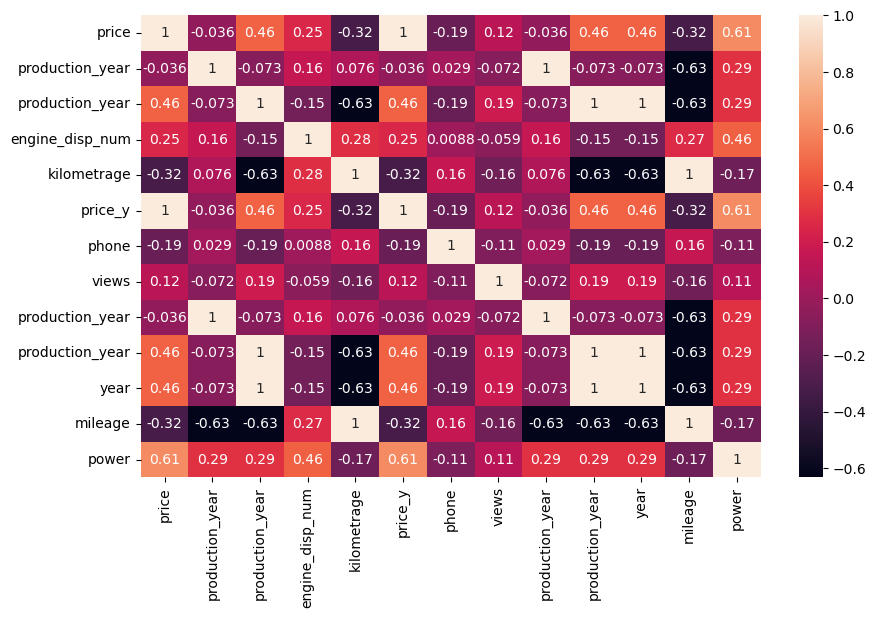

In [16]:
corr = df[num_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.show()

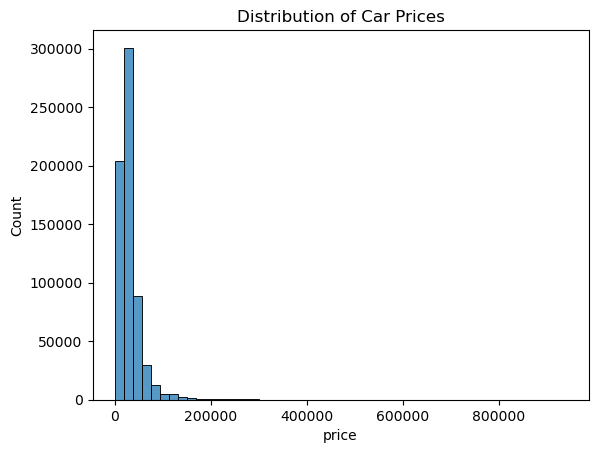

In [17]:
# Histogram
sns.histplot(df['price'], bins=50)
plt.title('Distribution of Car Prices')
plt.show()

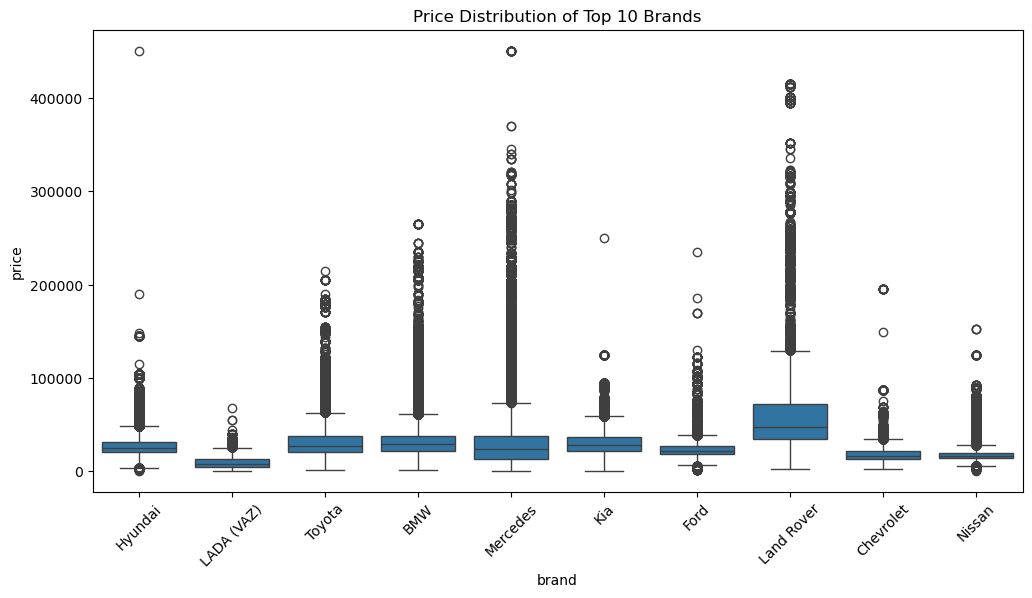

In [18]:
top_brands = df['brand'].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.boxplot(x='brand', y='price', data=df[df['brand'].isin(top_brands)])
plt.xticks(rotation=45)
plt.title('Price Distribution of Top 10 Brands')
plt.show()

# We have too many outliers. We'll check it after cleaning again.

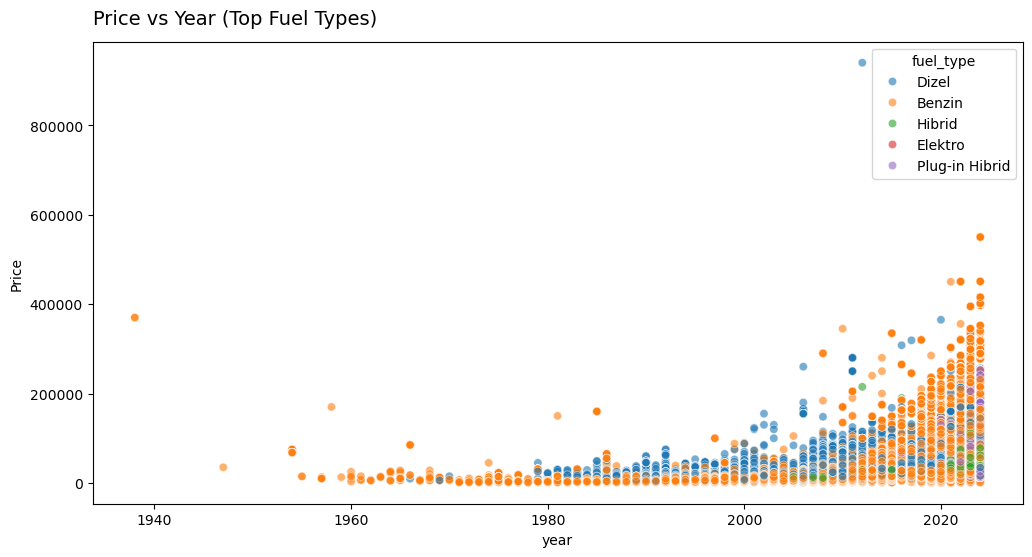

In [20]:
# Scatter: price vs year
top_fuels = df['fuel_type'].value_counts().head().index

plt.figure(figsize=(12,6))
sns.scatterplot(
    x='year',
    y='price',
    hue='fuel_type',
    data=df[df['fuel_type'].isin(top_fuels)],
    alpha=0.6
)

# Title-i sol yuxarı
plt.title('Price vs Year (Top Fuel Types)', loc='left', y=1.02, fontsize=14)
plt.ylabel('Price')
plt.show()

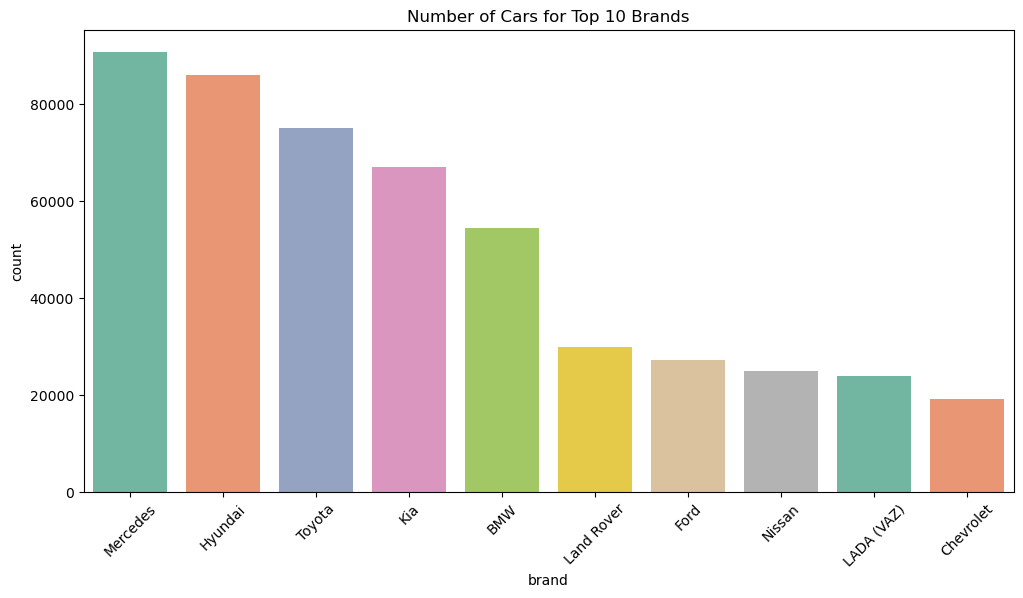

In [21]:
top_brands = df['brand'].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.countplot(x='brand', data=df[df['brand'].isin(top_brands)], 
              order=top_brands, palette='Set2')
plt.xticks(rotation=45)
plt.title('Number of Cars for Top 10 Brands')
plt.show()

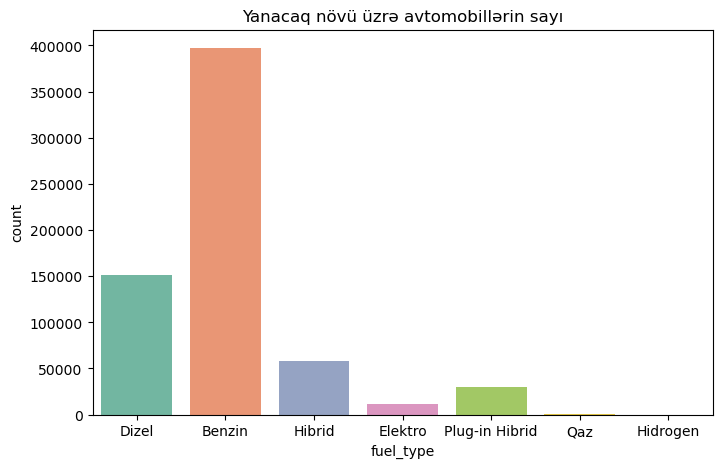

In [22]:
# Fuel type distribution
plt.figure(figsize=(8,5))
sns.countplot(x='fuel_type', data=df, palette='Set2')
plt.title('Yanacaq növü üzrə avtomobillərin sayı')
plt.show()

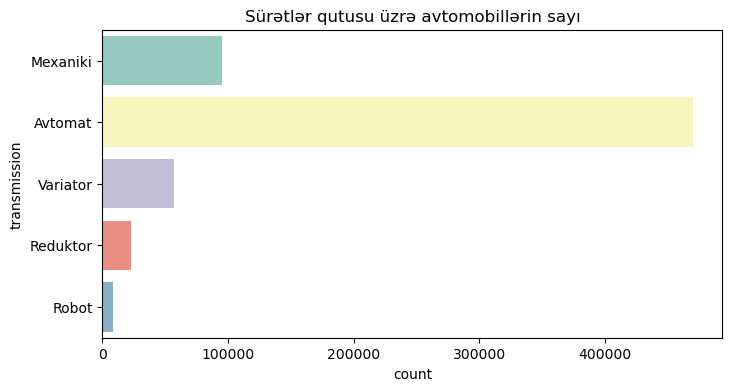

In [23]:
# Transmission distribution (horizontal bar)
plt.figure(figsize=(8,4))
sns.countplot(y='transmission', data=df, palette='Set3')
plt.title('Sürətlər qutusu üzrə avtomobillərin sayı')
plt.show()

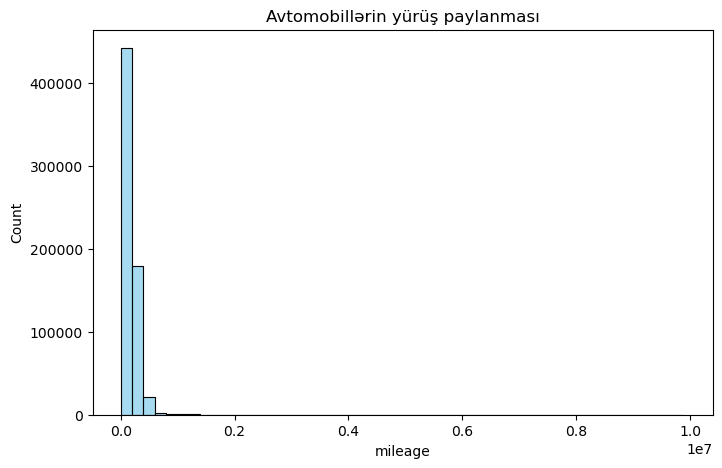

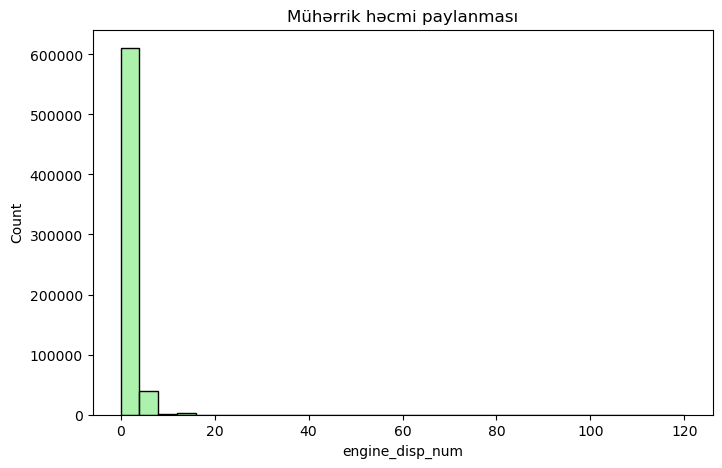

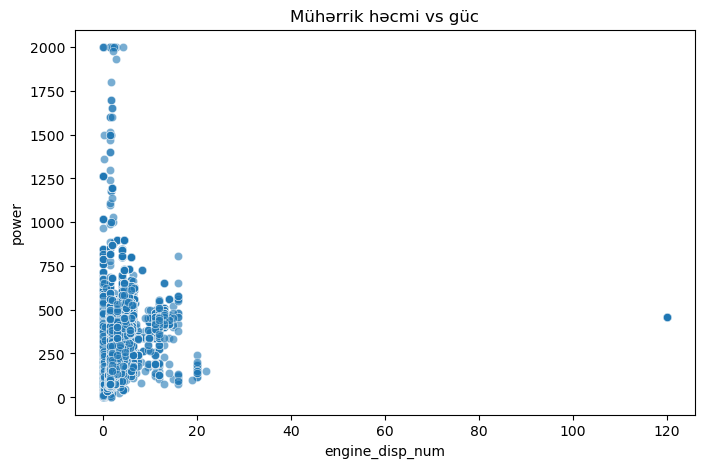

In [24]:
# Mileage histogram
plt.figure(figsize=(8,5))
sns.histplot(df['mileage'], bins=50, color='skyblue')
plt.title('Avtomobillərin yürüş paylanması')
plt.show()

# Engine size histogram
plt.figure(figsize=(8,5))
sns.histplot(df['engine_disp_num'], bins=30, color='lightgreen')
plt.title('Mühərrik həcmi paylanması')
plt.show()

# Power vs engine size
plt.figure(figsize=(8,5))
sns.scatterplot(x='engine_disp_num', y='power', data=df, alpha=0.6)
plt.title('Mühərrik həcmi vs güc')
plt.show()

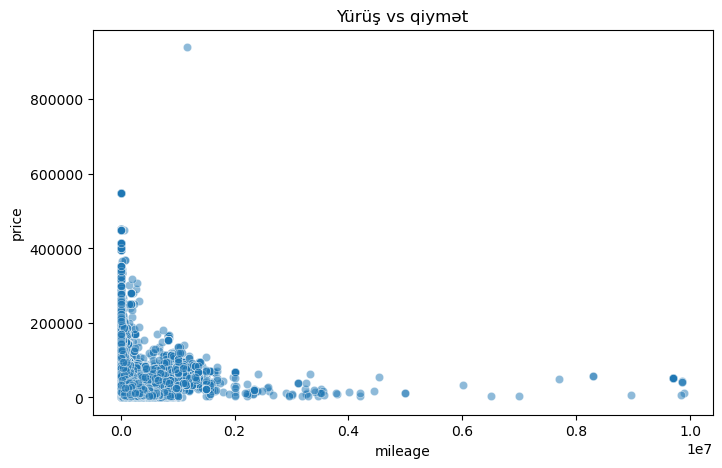

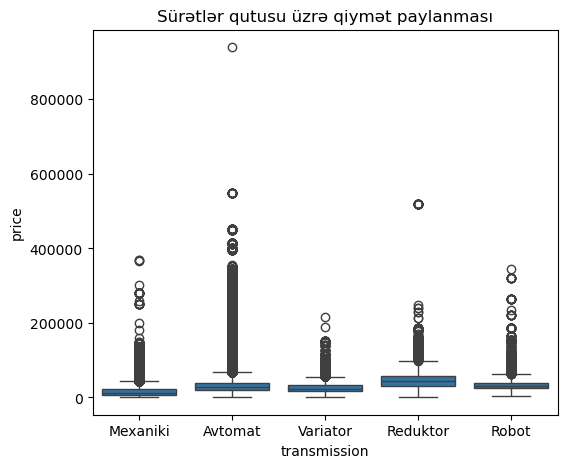

In [25]:
# Price vs Mileage
plt.figure(figsize=(8,5))
sns.scatterplot(x='mileage', y='price', data=df, alpha=0.5)
plt.title('Yürüş vs qiymət')
plt.ylabel('price')
plt.show()

# Boxplot: price vs transmission
plt.figure(figsize=(6,5))
sns.boxplot(x='transmission', y='price', data=df)
plt.title('Sürətlər qutusu üzrə qiymət paylanması')
plt.ylabel('price')
plt.show()

In [26]:
brand_price = df.groupby("brand")["price"].mean().sort_values(ascending=False)
brand_price.head(10)

brand
Rolls-Royce        438234.375
Lamborghini        322622.308
Mercedes-Maybach   191635.248
Bentley            181694.388
Yangwang           174999.000
Ferrari            168000.000
Daimler            160000.000
Lotus              132000.000
Genesis            121034.120
M-Hero             118038.462
Name: price, dtype: float64

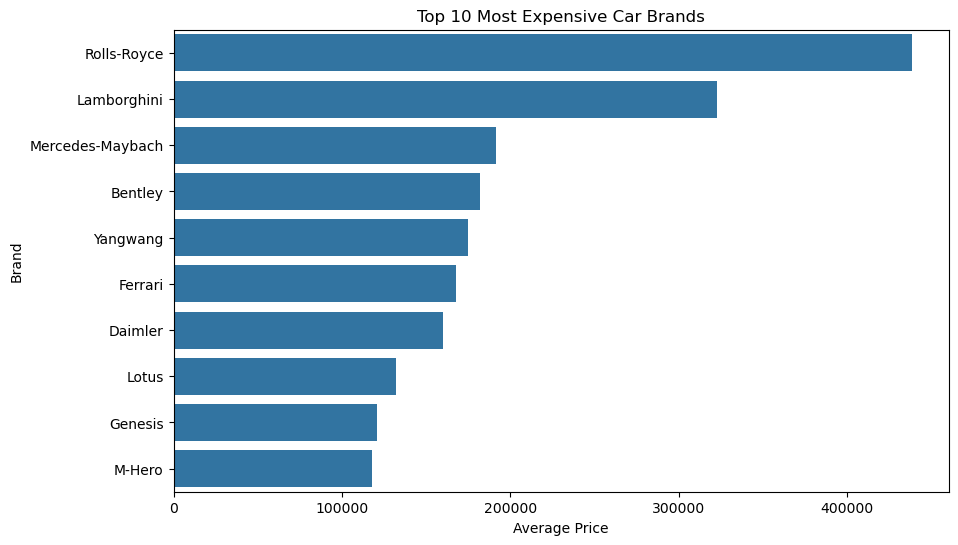

In [27]:
plt.figure(figsize=(10,6))
sns.barplot(x=brand_price.head(10).values, y=brand_price.head(10).index)
plt.title("Top 10 Most Expensive Car Brands")
plt.xlabel("Average Price")
plt.ylabel("Brand")
plt.show()

In [28]:
df[['year','price']].corr()

,year,price
year,1.000,0.459
price,0.459,1.000


In [170]:
sns.barplot(x= fuel_price.index, y= fuel_price.values)
plt.title("Average Price by Fuel Type")
plt.show() 

NameError: name 'fuel_price' is not defined

# EDA

In [33]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None )
pd.set_option('display.width', 300)

In [34]:
df = pd.read_csv("cars.csv")
df

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.000,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.600,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.000,AZN,Şəmi,NaN,507687355.000,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.700,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.000,AZN,NaN,Lada Azərbaycan,554092445.000,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.000,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.000,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.000,USD,Anar,NaN,502126242.000,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.000,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.000,AZN,Babək,NaN,774999004.000,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-

In [35]:
df.head()

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.000,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.600,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.000,AZN,Şəmi,NaN,507687355.000,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.700,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.000,AZN,NaN,Lada Azərbaycan,554092445.000,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.000,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.000,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.000,USD,Anar,NaN,502126242.000,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.000,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.000,AZN,Babək,NaN,774999004.000,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-

In [36]:
df.tail()

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
653716,16caa803-a546-455b-81ff-bc20868c2136,/autos/9081944-toyota-prius,2025-01-05 20:15:21.051803,Toyota Prius,10800.000,AZN,"Bakı, dünən 00:03",bakı,05.01.2025,00:03,"2008, 1.5 L, 320 000 km",2008,1.500,L,320000,km,Barter mümkündür,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,15770ce6-f9db-411e-baeb-5ca6e525e1eb,16caa803-a546-455b-81ff-bc20868c2136,/autos/9081944-toyota-prius,2025-01-05 20:23:28.915653,Maşın yaxşı vəziyətdədir heç bir prablemi yoxd...,10800.000,AZN,Nicat,NaN,513908085.000,05.01.2025,210,NaN,15770ce6-f9db-411e-baeb-5ca6e525e1eb,Liftbek,2008,NaN,Toyota,Prius,1.5 L / 76 a.g. / Hibrid,NaN,Qırmızı,2,Variator,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,320 000 km,Ön,Bakı,15770ce6-f9db-411e-baeb-5ca6e525e1eb,/autos/9081944-toyota-prius,Yüngül lehimli disklər* ABS* Yağış sensoru* Mə...
653717,2a26a6c1-8914-4b68-abb4-1fbd12ced7bc,/autos/9081939-uaz-hunter,2025-01-05 20:15:21.051803,UAZ Hunter,9500.000,AZN,"Göygöl, dünən 00:32",göygöl,05.01.2025,00:32,"2011, 2.9 L, 155 000 km",2011,2.900,L,155000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e73e0e76-a139-404e-bf43-875e16799544,2a26a6c1-8914-4b68-abb4-1fbd12ced7bc,/autos/9081939-uaz-hunter,2025-01-05 20:23:28.915653,2012 alış. İdeal vəziyyətdədir. Udar vuruğu yo...,9500.000,AZN,Tunar,NaN,102307845.000,05.01.2025,1195,NaN,e73e0e76-a139-404e-bf43-875e16799544,"Offroader / SUV, 5 qapı",2011,NaN,UAZ,Hunter,2.9 L / 135 a.g. / Benzin,NaN,Boz,0,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,155 000 km,Tam,Göygöl,e73e0e76-a139-404e-bf43-875e16799544,/autos/9081939-uaz-hunter,Yüngül lehimli disklər* Mərkəzi qapanma
653718,feb75615-0131-4d6f-b009-cc02faea4e01,/autos/9055034-hyundai-elantra,2025-01-05 20:15:21.051803,Hyundai Elantra,25400.000,AZN,"Bakı, dünən 00:00",bakı,05.01.2025,00:00,"2018, 2.0 L, 77 926 km",2018,2.000,L,77926,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,b7758882-a169-4351-9a14-a3692d9ee9c9,feb75615-0131-4d6f-b009-cc02faea4e01,/autos/9055034-hyundai-elantra,2025-01-05 20:23:28.915653,Amerikadan yeni gelib. Tex passport 2018. 2 sa...,25400.000,AZN,Kamran,NaN,553039009.000,05.01.2025,1120,5NPD84LF9JH337806,b7758882-a169-4351-9a14-a3692d9ee9c9,Sedan,2018,NaN,Hyundai,Elantra,2.0 L / 150 a.g. / Benzin,NaN,Göy,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,77 926 km,Ön,Bakı,b7758882-a169-4351-9a14-a3692d9ee9c9,/autos/9055034-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
653719,e5f8e957-5543-42be-b30f-78723ce551f9,/autos/9065903-jeep-grand-cherokee,2025-01-05 20:15:21.051803,Jeep Grand Cherokee,10600.000,AZN,"Kürdəmir, dünən 09:02",kürdəmir,05.01.2025,09:02,"1999, 4.7 L, 250 000 km",1999,4.700,L,250000,km,Barter mümkündür,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,37020736-2c34-4b02-b7f7-62e81cb72bb8,e5f8e957-5543-42be-b30f-78723ce551f9,/autos/9065903-jeep-grand-cherokee,2025-01-05 20:23:28.915653,Təcili Satılır real alıcıya endirim olacaq be...,10600.000,AZN,Ayxan,NaN,503331158.000,05.01.2025,1320,NaN,37020736-2c34-4b02-b7f7-62e81cb72bb8,"Offroader / SUV, 5 qapı",1999,Amerika,Jeep,Grand Cherokee,4.7 L / 258 a.g. / Benzin,NaN,Qara,2,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,250 000 km,Tam,Kürdəmir,37020736-2c34-4b02-b7f7-62e81cb72bb8,/autos/9065903-jeep-grand-cherokee,Yüngül lehimli disklər* ABS* Lyuk* Kondisioner...
653720,a59362fe-117b-4b1c-bd43-636f1469cdbb,/autos/9077

In [37]:
df.shape

(653721, 56)

In [38]:
df.columns

Index(['id_x', 'car_rel_url_x', 'datetime_scrape', 'name', 'price_x', 'currency_x', 'datetime_product', 'city', 'day', 'hour', 'attributes', 'production_year', 'engine_displacement_num', 'engine_displacement_unit', 'kilometrage_num', 'kilometrage_unit', 'barter', 'loan', 'salon', 'spare_parts',
       'vip', 'featured', 'img_url', 'id_y', 'cars_id', 'car_rel_url_y', 'datetime', 'description', 'price_y', 'currency_y', 'owner_name', 'shop_name', 'phone', 'updated', 'views', 'vin', 'car_details_id_x', 'Ban növü', 'Buraxılış ili', 'Hansı bazar üçün yığılıb', 'Marka', 'Model', 'Mühərrik',
       'Qəzalı', 'Rəng', 'Sahiblər', 'Sürətlər qutusu', 'Vəziyyəti', 'Yeni', 'Yerlərin sayı', 'Yürüş', 'Ötürücü', 'Şəhər', 'car_details_id_y', 'car_rel_url', 'extra_info'],
      dtype='object')

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 653721 entries, 0 to 653720
Data columns (total 56 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id_x                      653721 non-null  object 
 1   car_rel_url_x             653721 non-null  object 
 2   datetime_scrape           653721 non-null  object 
 3   name                      653721 non-null  object 
 4   price_x                   653721 non-null  float64
 5   currency_x                653721 non-null  object 
 6   datetime_product          653721 non-null  object 
 7   city                      653721 non-null  object 
 8   day                       653721 non-null  object 
 9   hour                      653721 non-null  object 
 10  attributes                653721 non-null  object 
 11  production_year           653721 non-null  int64  
 12  engine_displacement_num   653721 non-null  float64
 13  engine_displacement_unit  647933 non-null  o

In [40]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price_x,653721.000,31630.966,28679.361,500.000,16800.000,25300.000,36800.000,940000.000
production_year,653721.000,1995.887,188.794,0.000,2009.000,2015.000,2019.000,2024.000
engine_displacement_num,653721.000,2.221,1.266,0.000,1.600,2.000,2.500,120.000
kilometrage_num,653721.000,156523.123,145894.858,0.000,55022.000,145000.000,222333.000,9900025.000
price_y,653721.000,31630.918,28679.394,500.000,16800.000,25300.000,36800.000,940000.000
phone,653456.000,558941474.943,151671835.115,78.000,506001358.500,552402929.000,558882698.000,999999690.000
views,653721.000,3740.732,10299.033,12.000,432.000,1367.000,3412.000,359317.000
Buraxılış ili,653721.000,2013.798,7.646,1938.000,2009.000,2015.000,2019.000,2024.000


In [41]:
df.isnull().values.any()
#nan, nulllari yoxluyur

True

In [42]:
df.isnull().sum()
#her sutun uzre bos xanalarin sayi

id_x                             0
car_rel_url_x                    0
datetime_scrape                  0
name                             0
price_x                          0
currency_x                       0
datetime_product                 0
city                             0
day                              0
hour                             0
attributes                       0
production_year                  0
engine_displacement_num          0
engine_displacement_unit      5788
kilometrage_num                  0
kilometrage_unit              5788
barter                      428168
loan                        490381
salon                       460382
spare_parts                 651959
vip                         364780
featured                    489886
img_url                          0
id_y                             0
cars_id                          0
car_rel_url_y                    0
datetime                         0
description                  15529
price_y             

In [43]:
def check_df(dataframe, head = 5):
    print("                      Shape                      ")
    print(dataframe.shape)
    print('\n')
    print("                      Types                      ")
    print(dataframe.dtypes)
    print('\n')
    print("                      Head                      ")
    print(dataframe.head(head))
    print('\n')
    print("                      Tail                      ")
    print()
    print(dataframe.tail(head))
    print('\n')
    print("                      NAN                      ")
    print(dataframe.isnull().sum())
    print('\n')
    print("                      Info                      ")
    print(dataframe.info())
    print("\n")
    print("                      Quantiles                      ")
    print(dataframe.describe([0, 0.05, 0.50, 0.95, 0.99, 1]).T)
    print('\n')
# datasetin butun melumatlari bir kodda

In [44]:
check_df(df)

                      Shape                      
(653721, 56)


                      Types                      
id_x                         object
car_rel_url_x                object
datetime_scrape              object
name                         object
price_x                     float64
currency_x                   object
datetime_product             object
city                         object
day                          object
hour                         object
attributes                   object
production_year               int64
engine_displacement_num     float64
engine_displacement_unit     object
kilometrage_num               int64
kilometrage_unit             object
barter                       object
loan                         object
salon                        object
spare_parts                  object
vip                          object
featured                     object
img_url                      object
id_y                         object
cars_id              

##  Analysis of Categorical Variables

In [45]:
df = pd.read_csv("cars.csv")
df.head()

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.000,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.600,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.000,AZN,Şəmi,NaN,507687355.000,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.700,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.000,AZN,NaN,Lada Azərbaycan,554092445.000,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.000,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.000,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.000,USD,Anar,NaN,502126242.000,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.000,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.000,AZN,Babək,NaN,774999004.000,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-

In [46]:
df["engine_displacement_num"].value_counts()
#deyer sayi

engine_displacement_num
2.000     165534
1.500      76947
1.600      59122
3.000      48921
2.200      42430
           ...  
8.000          2
6.800          2
4.100          2
22.000         1
19.000         1
Name: count, Length: 88, dtype: int64

In [47]:
df["name"].unique()
# tekrar adlari cixaraq, ferqlileri gosterir

array(['Hyundai i30', 'LADA (VAZ) Niva Travel', 'Toyota Land Cruiser',
       ..., 'Suzuki V-Strom 800 RQ', 'Mercedes ML 230 4MATIC',
       'MAN TGA 26.320'], dtype=object)

In [48]:
df["name"].nunique()
#ferqlilerin sayi

2530

In [49]:
cat_cols = [col for col in df.columns if str(df[col].dtypes) in ["category", "object", "bool"]]
cat_cols

['id_x',
 'car_rel_url_x',
 'datetime_scrape',
 'name',
 'currency_x',
 'datetime_product',
 'city',
 'day',
 'hour',
 'attributes',
 'engine_displacement_unit',
 'kilometrage_unit',
 'barter',
 'loan',
 'salon',
 'spare_parts',
 'vip',
 'featured',
 'img_url',
 'id_y',
 'cars_id',
 'car_rel_url_y',
 'datetime',
 'description',
 'currency_y',
 'owner_name',
 'shop_name',
 'updated',
 'vin',
 'car_details_id_x',
 'Ban növü',
 'Hansı bazar üçün yığılıb',
 'Marka',
 'Model',
 'Mühərrik',
 'Qəzalı',
 'Rəng',
 'Sahiblər',
 'Sürətlər qutusu',
 'Vəziyyəti',
 'Yeni',
 'Yerlərin sayı',
 'Yürüş',
 'Ötürücü',
 'Şəhər',
 'car_details_id_y',
 'car_rel_url',
 'extra_info']

In [50]:
num_but_cat = [col for col in df.columns if df[col].nunique() < 4 and df[col].dtypes in ["int", "float"]]
num_but_cat

[]

In [51]:
cat_but_car = [col for col in df.columns if df[col].nunique() > 20 and str(df[col].dtypes) in ["category", "object"]]
cat_but_car

['id_x',
 'car_rel_url_x',
 'datetime_scrape',
 'name',
 'datetime_product',
 'city',
 'day',
 'hour',
 'attributes',
 'img_url',
 'id_y',
 'cars_id',
 'car_rel_url_y',
 'datetime',
 'description',
 'owner_name',
 'shop_name',
 'updated',
 'vin',
 'car_details_id_x',
 'Ban növü',
 'Marka',
 'Model',
 'Mühərrik',
 'Yürüş',
 'Şəhər',
 'car_details_id_y',
 'car_rel_url',
 'extra_info']

In [52]:
cat_cols = cat_cols + num_but_cat
cat_cols
# kategory columnlarla , numerical gorunub kategori olan columnlarin cemi

['id_x',
 'car_rel_url_x',
 'datetime_scrape',
 'name',
 'currency_x',
 'datetime_product',
 'city',
 'day',
 'hour',
 'attributes',
 'engine_displacement_unit',
 'kilometrage_unit',
 'barter',
 'loan',
 'salon',
 'spare_parts',
 'vip',
 'featured',
 'img_url',
 'id_y',
 'cars_id',
 'car_rel_url_y',
 'datetime',
 'description',
 'currency_y',
 'owner_name',
 'shop_name',
 'updated',
 'vin',
 'car_details_id_x',
 'Ban növü',
 'Hansı bazar üçün yığılıb',
 'Marka',
 'Model',
 'Mühərrik',
 'Qəzalı',
 'Rəng',
 'Sahiblər',
 'Sürətlər qutusu',
 'Vəziyyəti',
 'Yeni',
 'Yerlərin sayı',
 'Yürüş',
 'Ötürücü',
 'Şəhər',
 'car_details_id_y',
 'car_rel_url',
 'extra_info']

In [53]:
cat_cols = [col for col in cat_cols if col not in cat_but_car]
cat_cols

['currency_x',
 'engine_displacement_unit',
 'kilometrage_unit',
 'barter',
 'loan',
 'salon',
 'spare_parts',
 'vip',
 'featured',
 'currency_y',
 'Hansı bazar üçün yığılıb',
 'Qəzalı',
 'Rəng',
 'Sahiblər',
 'Sürətlər qutusu',
 'Vəziyyəti',
 'Yeni',
 'Yerlərin sayı',
 'Ötürücü']

In [54]:
df[cat_cols].nunique()

currency_x                   3
engine_displacement_unit     1
kilometrage_unit             1
barter                       1
loan                         1
salon                        1
spare_parts                  1
vip                          1
featured                     1
currency_y                   3
Hansı bazar üçün yığılıb     9
Qəzalı                       1
Rəng                        18
Sahiblər                     5
Sürətlər qutusu              5
Vəziyyəti                    4
Yeni                         2
Yerlərin sayı                8
Ötürücü                      3
dtype: int64

In [55]:
[col for col in df.columns if col not in cat_cols]

['id_x',
 'car_rel_url_x',
 'datetime_scrape',
 'name',
 'price_x',
 'datetime_product',
 'city',
 'day',
 'hour',
 'attributes',
 'production_year',
 'engine_displacement_num',
 'kilometrage_num',
 'img_url',
 'id_y',
 'cars_id',
 'car_rel_url_y',
 'datetime',
 'description',
 'price_y',
 'owner_name',
 'shop_name',
 'phone',
 'updated',
 'views',
 'vin',
 'car_details_id_x',
 'Ban növü',
 'Buraxılış ili',
 'Marka',
 'Model',
 'Mühərrik',
 'Yürüş',
 'Şəhər',
 'car_details_id_y',
 'car_rel_url',
 'extra_info']

In [56]:
df["engine_displacement_num"].value_counts()

engine_displacement_num
2.000     165534
1.500      76947
1.600      59122
3.000      48921
2.200      42430
           ...  
8.000          2
6.800          2
4.100          2
22.000         1
19.000         1
Name: count, Length: 88, dtype: int64

In [57]:
20 * df["engine_displacement_num"].value_counts() / len(df)

engine_displacement_num
2.000    5.064
1.500    2.354
1.600    1.809
3.000    1.497
2.200    1.298
          ... 
8.000    0.000
6.800    0.000
4.100    0.000
22.000   0.000
19.000   0.000
Name: count, Length: 88, dtype: float64

In [59]:
def cat_summary(dataframe, col_name):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
# deyer sayi ve faiz hesabi
    print("----------------------------------")

In [60]:
cat_summary(df, "engine_displacement_num")

                         engine_displacement_num  Ratio
engine_displacement_num                                
2.000                                     165534 25.322
1.500                                      76947 11.771
1.600                                      59122  9.044
3.000                                      48921  7.483
2.200                                      42430  6.491
...                                          ...    ...
8.000                                          2  0.000
6.800                                          2  0.000
4.100                                          2  0.000
22.000                                         1  0.000
19.000                                         1  0.000

[88 rows x 2 columns]
----------------------------------


In [61]:
for col in cat_cols:
    cat_summary(df, col)

            currency_x  Ratio
currency_x                   
AZN             465598 71.223
$               182236 27.877
€                 5887  0.901
----------------------------------
                          engine_displacement_unit  Ratio
engine_displacement_unit                                 
L                                           647933 99.115
----------------------------------
                  kilometrage_unit  Ratio
kilometrage_unit                         
km                          647933 99.115
----------------------------------
                  barter  Ratio
barter                         
Barter mümkündür  225553 34.503
----------------------------------
               loan  Ratio
loan                      
Kreditdədir  163340 24.986
----------------------------------
        salon  Ratio
salon               
Salon  193339 29.575
----------------------------------
             spare_parts  Ratio
spare_parts                    
Qəzalı              1762  0.270
----

In [62]:
def cat_summary(dataframe, col_name, plot = False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("----------------------------------")
    if plot:
        sns.countplot(x = dataframe[col_name], data = df) #lazim olan sutunlarin hansi cedvelden goturulmesi
        plt.show(block = True) # qrafiki ekrana cixarir 

                         name  Ratio
name                                
Kia Sorento             23185  3.547
Hyundai Elantra         19004  2.907
Hyundai Santa Fe        17858  2.732
Land Rover Range Rover  16857  2.579
Hyundai Sonata          16042  2.454
...                       ...    ...
UAZ 3153                    1  0.000
Vespa Primavera 150         1  0.000
MAZ 551605                  1  0.000
Mondial 100 Loyal           1  0.000
MAN TGA 26.320              1  0.000

[2530 rows x 2 columns]
----------------------------------


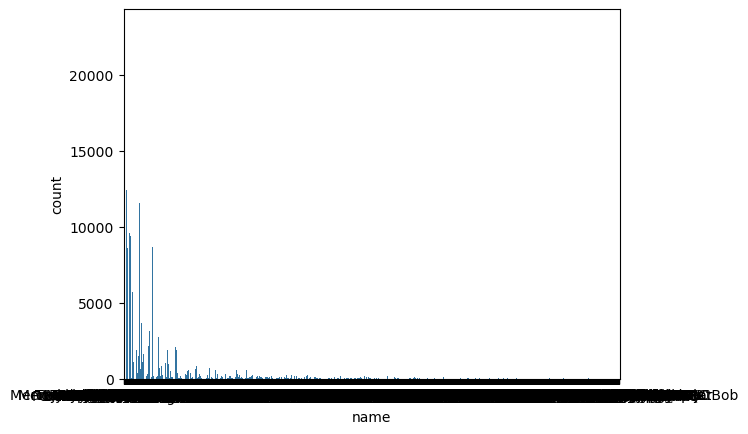

In [63]:
cat_summary(df, "name", plot = True)

In [64]:
df["Marka"]=df["Marka"].astype("category")
df["Marka"] # sutunlar ferqli tipdedise onlarin kategoriye cevrilmesi

0            Hyundai
1         LADA (VAZ)
2             Toyota
3            Hyundai
4             Toyota
             ...    
653716        Toyota
653717           UAZ
653718       Hyundai
653719          Jeep
653720    Land Rover
Name: Marka, Length: 653721, dtype: category
Categories (208, object): ['ATV', 'Abarth', 'Acura', 'Alfa Romeo', ..., 'Zamyad', 'Zongshen', 'Zontes', 'iCar']

            currency_x  Ratio
currency_x                   
AZN             465598 71.223
$               182236 27.877
€                 5887  0.901
----------------------------------


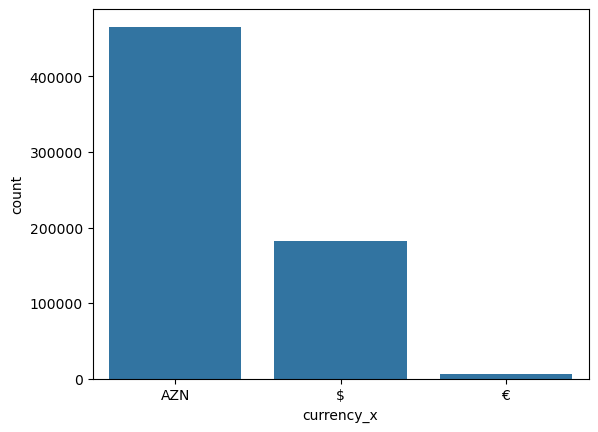

                          engine_displacement_unit  Ratio
engine_displacement_unit                                 
L                                           647933 99.115
----------------------------------


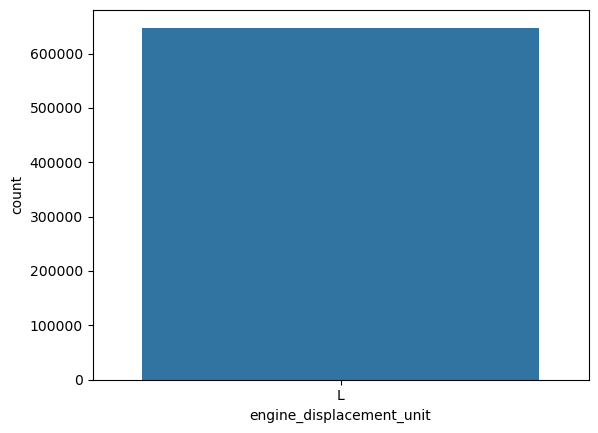

                  kilometrage_unit  Ratio
kilometrage_unit                         
km                          647933 99.115
----------------------------------


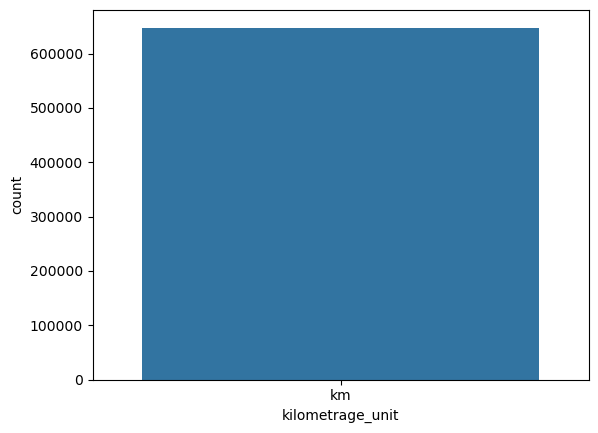

                  barter  Ratio
barter                         
Barter mümkündür  225553 34.503
----------------------------------


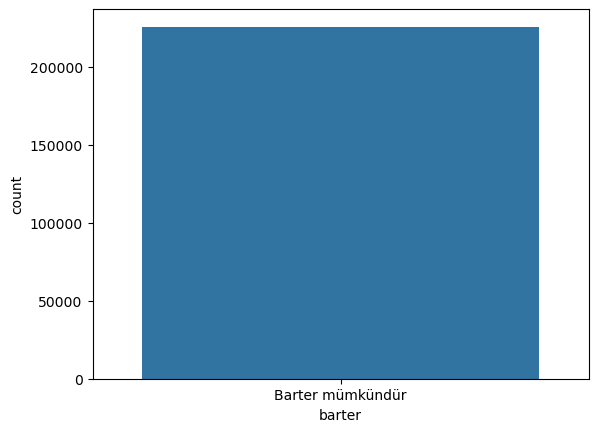

               loan  Ratio
loan                      
Kreditdədir  163340 24.986
----------------------------------


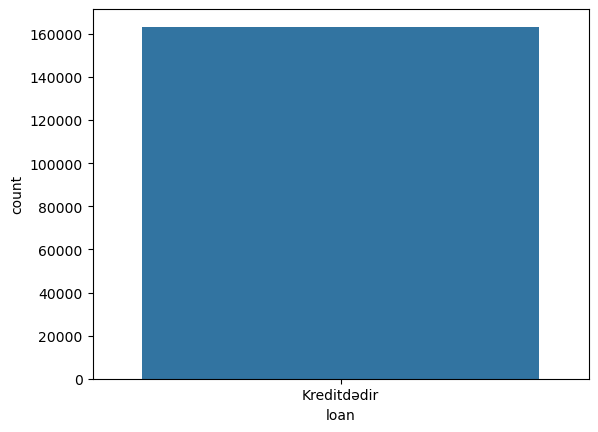

        salon  Ratio
salon               
Salon  193339 29.575
----------------------------------


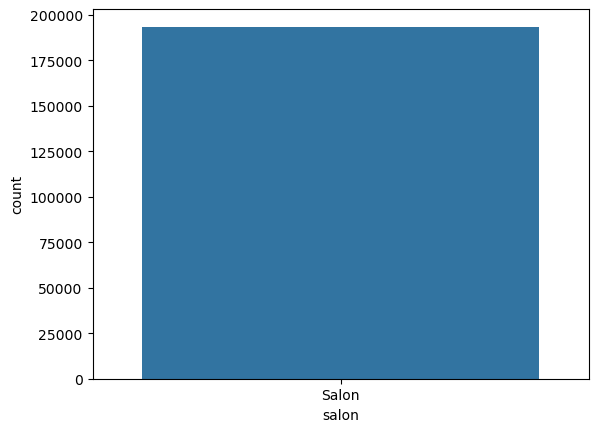

             spare_parts  Ratio
spare_parts                    
Qəzalı              1762  0.270
----------------------------------


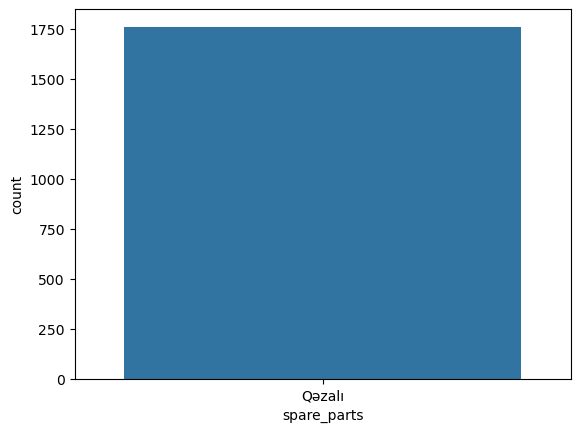

                vip  Ratio
vip                       
vipped-icon  288941 44.199
----------------------------------


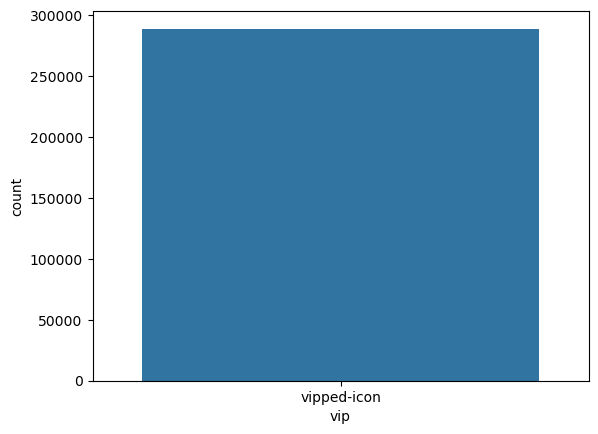

               featured  Ratio
featured                      
featured-icon    163835 25.062
----------------------------------


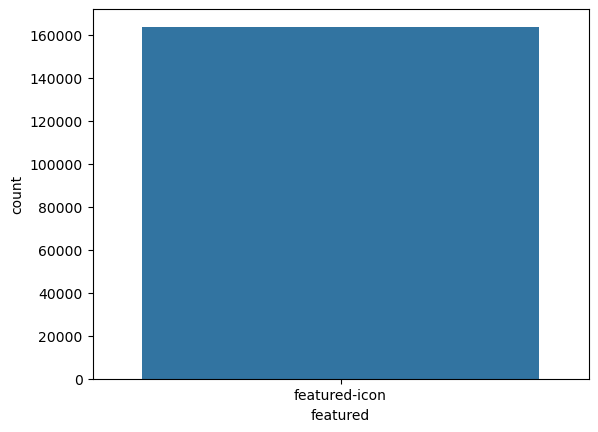

            currency_y  Ratio
currency_y                   
AZN             465596 71.222
USD             182239 27.877
EUR               5886  0.900
----------------------------------


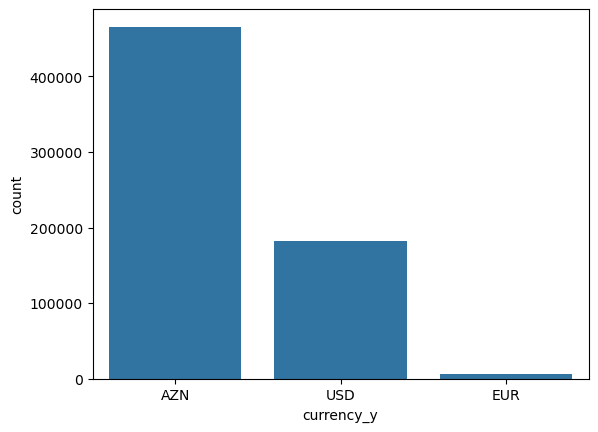

                          Hansı bazar üçün yığılıb  Ratio
Hansı bazar üçün yığılıb                                 
Rəsmi diler                                 118333 18.101
Avropa                                      105315 16.110
Amerika                                     103217 15.789
Koreya                                       61449  9.400
Yaponiya                                     19123  2.925
Çin                                          18496  2.829
Digər                                        18148  2.776
Rusiya                                       14496  2.217
Dubay                                         5639  0.863
----------------------------------


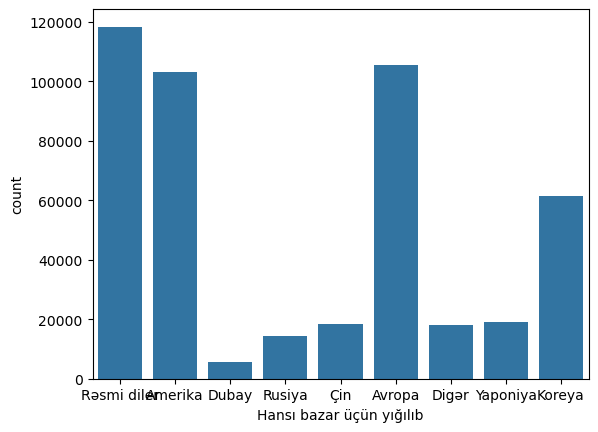

        Qəzalı  Ratio
Qəzalı               
Bəli      1761  0.269
----------------------------------


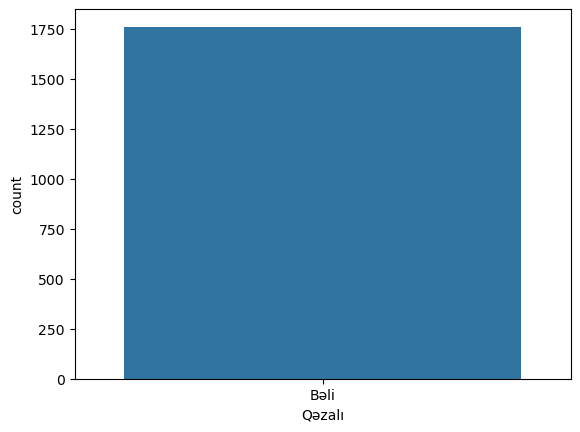

                Rəng  Ratio
Rəng                       
Ağ            205976 31.508
Qara          187966 28.753
Yaş Asfalt     60681  9.282
Gümüşü         57536  8.801
Göy            47048  7.197
Boz            38779  5.932
Qırmızı        10300  1.576
Tünd qırmızı    8933  1.366
Mavi            7376  1.128
Yaşıl           7272  1.112
Qəhvəyi         5242  0.802
Qızılı          5061  0.774
Bej             3435  0.525
Açıq yaşıl      2986  0.457
Narıncı         2020  0.309
Sarı            1348  0.206
Bənövşəyi       1156  0.177
Çəhrayı          606  0.093
----------------------------------


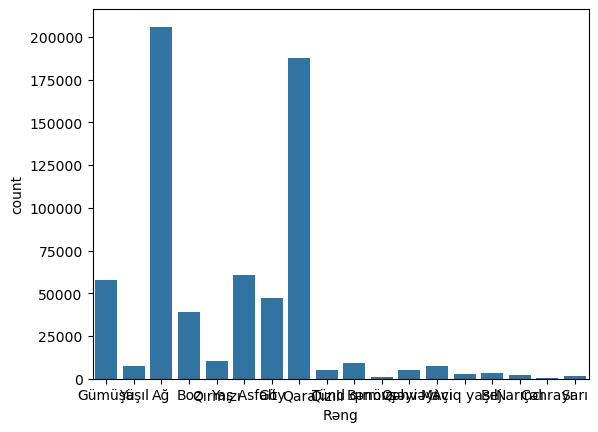

               Sahiblər  Ratio
Sahiblər                      
1                207016 31.667
2                128779 19.699
0                 75150 11.496
3                 17966  2.748
4 və daha çox      3189  0.488
----------------------------------


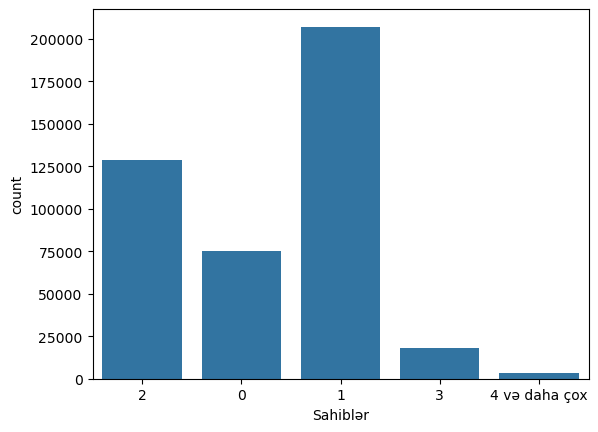

                 Sürətlər qutusu  Ratio
Sürətlər qutusu                        
Avtomat                   469853 71.874
Mexaniki                   95477 14.605
Variator                   56987  8.717
Reduktor                   23143  3.540
Robot                       8261  1.264
----------------------------------


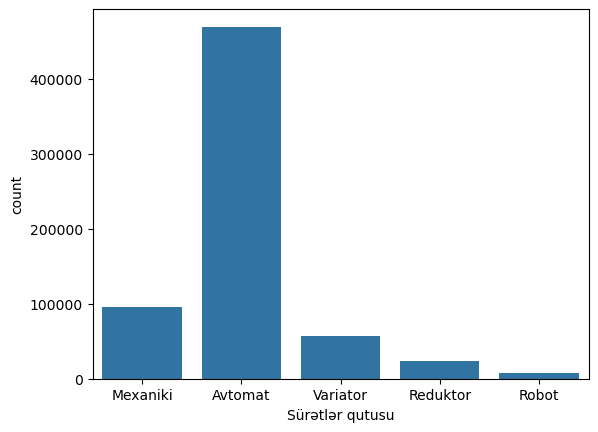

                             Vəziyyəti  Ratio
Vəziyyəti                                    
Vuruğu yoxdur, rənglənməyib     615492 94.152
Vuruğu yoxdur, rənglənib         31768  4.860
Vuruğu var, rənglənib             3586  0.549
Vuruğu var, rənglənməyib          2872  0.439
----------------------------------


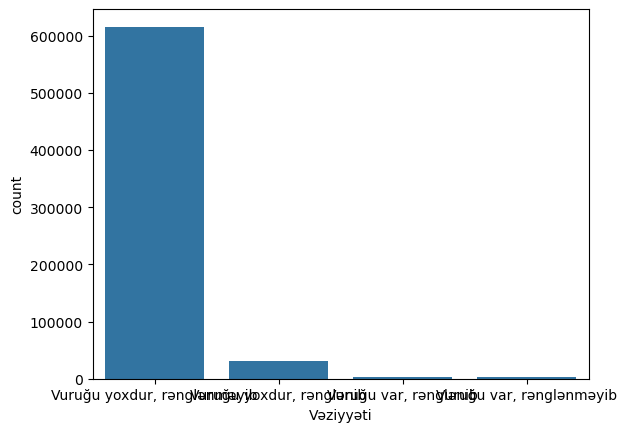

        Yeni  Ratio
Yeni               
Xeyr  565159 86.453
Bəli   88562 13.547
----------------------------------


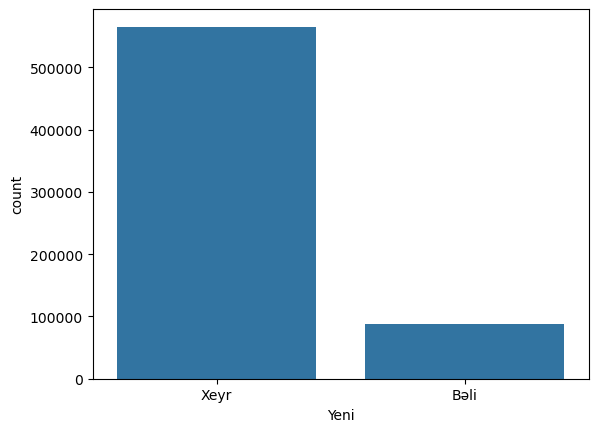

               Yerlərin sayı  Ratio
Yerlərin sayı                      
5                     354911 54.291
7                      67878 10.383
4                      35447  5.422
3                      14437  2.208
2                       5796  0.887
8+                      4736  0.724
6                       3960  0.606
1                        725  0.111
----------------------------------


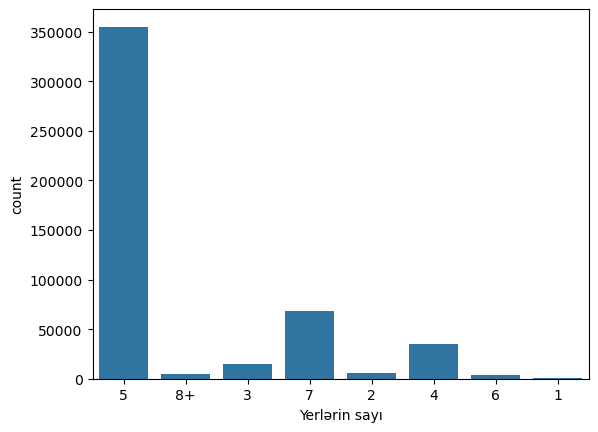

         Ötürücü  Ratio
Ötürücü                
Ön        317028 48.496
Tam       187243 28.643
Arxa      149450 22.861
----------------------------------


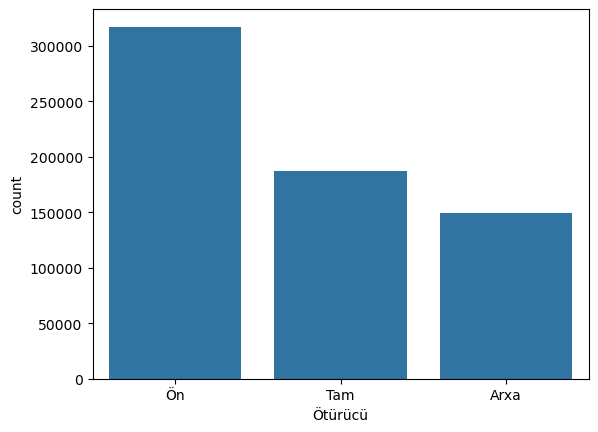

In [65]:
for col in cat_cols:
    if df[col].dtypes == "bool":
        df[col] = df[col].astype(category)
        cat_summary(df, col, plot = True) # eger sutun 'bool' tipindedise 'category'e cevir
    else:
        cat_summary(df, col, plot = True) # eks halda funksiyani ise sal

In [66]:
def cat_summary(dataframe, col_name, plot = False):
    if dataframe[col_name].dtypes == "bool":
        dataframe[col_name] = dataframe[col_name].astype(int) # bool tipindedise int-e cevir
        print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                            "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)})) # sutunun deyer sayini, ve faizini  cixarir
        print("-----------------------------") # seliqe
        if plot:
            sns.countplot(x=dataframe[col_name], data = dataframe)#qrafiki cekir
            plt.show(block=True) # ekrana cixarir
    else:
        print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                            "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
        print("-----------------------------")
        if plot:
            sns.countplot(x=dataframe[col_name], data = dataframe)
            plt.show(block = True)

                         name  Ratio
name                                
Kia Sorento             23185  3.547
Hyundai Elantra         19004  2.907
Hyundai Santa Fe        17858  2.732
Land Rover Range Rover  16857  2.579
Hyundai Sonata          16042  2.454
...                       ...    ...
UAZ 3153                    1  0.000
Vespa Primavera 150         1  0.000
MAZ 551605                  1  0.000
Mondial 100 Loyal           1  0.000
MAN TGA 26.320              1  0.000

[2530 rows x 2 columns]
-----------------------------


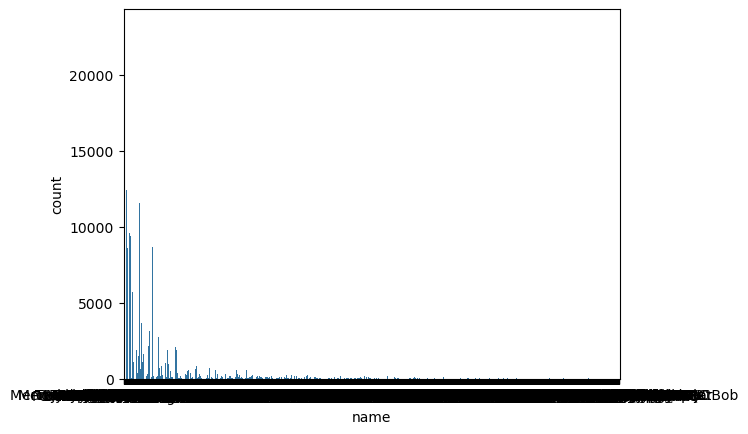

In [67]:
cat_summary(df, "name", plot = True)

In [68]:
def cat_summary(dataframe, col_name):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("--------------------")

In [69]:
cat_summary(df, "Marka") # Datasetden markalarin sayi, ve faizle ifadesi

            Marka  Ratio
Marka                   
Mercedes    90830 13.894
Hyundai     85968 13.151
Toyota      75167 11.498
Kia         67029 10.253
BMW         54432  8.326
...           ...    ...
Xin Kai         1  0.000
Shuanghuan      1  0.000
Brilliance      1  0.000
Megelli         1  0.000
Vauxhall        1  0.000

[208 rows x 2 columns]
--------------------


##  Analysis of Numerical Variables

In [70]:
df = pd.read_csv("cars.csv")
df.head()

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.000,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.600,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.000,AZN,Şəmi,NaN,507687355.000,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.700,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.000,AZN,NaN,Lada Azərbaycan,554092445.000,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.000,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.000,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.000,USD,Anar,NaN,502126242.000,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.000,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.000,AZN,Babək,NaN,774999004.000,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-

In [71]:
cat_cols = [col for col in df.columns if str(df[col].dtypes) in ["category", "object", "bool"]]
#Datasetde category, bool, object tipinde olan sutunlari liste yigir
num_but_cat = [col for col in df.columns if df[col].nunique() < 5 and df[col].dtypes in ["int", "float"]]
#Rəqəm tipində olub cəmi 5-dən az fərqli dəyəri olanları
cat_but_car = [col for col in df.columns if df[col].nunique() > 15 and str(df[col].dtypes) in ["category", "object"]]
#15 den cox ferqli deyeri olanlari tapir
cat_cols = cat_cols + num_but_cat
cat_cols = [col for col in cat_cols if col not in cat_but_car]

In [72]:
df[["attributes","price_x"]].describe().T

,count,mean,std,min,25%,50%,75%,max
price_x,653721.000,31630.966,28679.361,500.000,16800.000,25300.000,36800.000,940000.000


In [73]:
num_cols = [col for col in df.columns if df[col].dtypes in ["int","float"]]
num_cols = [col for col in num_cols if col not in cat_cols]
num_cols

['price_x', 'engine_displacement_num', 'price_y', 'phone']

In [74]:
def num_summary(dataframe, numerical_col):
    quantiles = [0.05, 0.15, 0.19, 0.30, 0.40, 0.55, 0.60, 0.71, 0.8763, 0.90, 0.95]
    print(dataframe[numerical_col].describe(quantiles).T)# numerical sutunlar ve quantile tesviri

In [75]:
num_summary(df, "price_x")

count   653721.000
mean     31630.966
std      28679.361
min        500.000
5%        7600.000
15%      12700.000
19%      14300.000
30%      18800.000
40%      22200.000
50%      25300.000
55%      27000.000
60%      29000.000
71%      34500.000
87.6%    49900.000
90%      55000.000
95%      74500.000
max     940000.000
Name: price_x, dtype: float64


In [76]:
for col in num_cols:
    num_summary(df, col)
    print("---------------------------------\n")

count   653721.000
mean     31630.966
std      28679.361
min        500.000
5%        7600.000
15%      12700.000
19%      14300.000
30%      18800.000
40%      22200.000
50%      25300.000
55%      27000.000
60%      29000.000
71%      34500.000
87.6%    49900.000
90%      55000.000
95%      74500.000
max     940000.000
Name: price_x, dtype: float64
---------------------------------

count   653721.000
mean         2.221
std          1.266
min          0.000
5%           1.200
15%          1.500
19%          1.500
30%          1.600
40%          2.000
50%          2.000
55%          2.000
60%          2.000
71%          2.400
87.6%        3.000
90%          3.300
95%          4.000
max        120.000
Name: engine_displacement_num, dtype: float64
---------------------------------

count   653721.000
mean     31630.918
std      28679.394
min        500.000
5%        7600.000
15%      12700.000
19%      14300.000
30%      18800.000
40%      22200.000
50%      25300.000
55%      27000.000

In [77]:
def num_summary(dataframe, numerical_col, plot = False):
    quantiles = [0.05, 0.15, 0.19, 0.30, 0.40, 0.55, 0.60, 0.71, 0.8763, 0.90, 0.95]
    print(dataframe[numerical_col].describe(quantiles).T)
     #statistika ve vizualligin birlesmesi
    if plot:
        dataframe[numerical_col].hist()
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block = True)

In [78]:
num_summary(df, "Marka")

count       653721
unique         208
top       Mercedes
freq         90830
Name: Marka, dtype: object


In [79]:
for col in num_cols:
    num_summary(df, col)
    print("---------------\n")

count   653721.000
mean     31630.966
std      28679.361
min        500.000
5%        7600.000
15%      12700.000
19%      14300.000
30%      18800.000
40%      22200.000
50%      25300.000
55%      27000.000
60%      29000.000
71%      34500.000
87.6%    49900.000
90%      55000.000
95%      74500.000
max     940000.000
Name: price_x, dtype: float64
---------------

count   653721.000
mean         2.221
std          1.266
min          0.000
5%           1.200
15%          1.500
19%          1.500
30%          1.600
40%          2.000
50%          2.000
55%          2.000
60%          2.000
71%          2.400
87.6%        3.000
90%          3.300
95%          4.000
max        120.000
Name: engine_displacement_num, dtype: float64
---------------

count   653721.000
mean     31630.918
std      28679.394
min        500.000
5%        7600.000
15%      12700.000
19%      14300.000
30%      18800.000
40%      22200.000
50%      25300.000
55%      27000.000
60%      29000.000
71%      34500.0

In [80]:
def num_summary(dataframe, numerical_col, plot = False):
    quantiles = [0.05, 0.15, 0.19, 0.30, 0.40, 0.55, 0.60, 0.71, 0.8763, 0.90, 0.95]
    print(dataframe[numerical_col].describe(quantiles).T)
#statistika ve viziuallasdirma
    if plot:
        dataframe[numerical_col].hist()
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block = True)

count   653721.000
mean     31630.966
std      28679.361
min        500.000
5%        7600.000
15%      12700.000
19%      14300.000
30%      18800.000
40%      22200.000
50%      25300.000
55%      27000.000
60%      29000.000
71%      34500.000
87.6%    49900.000
90%      55000.000
95%      74500.000
max     940000.000
Name: price_x, dtype: float64


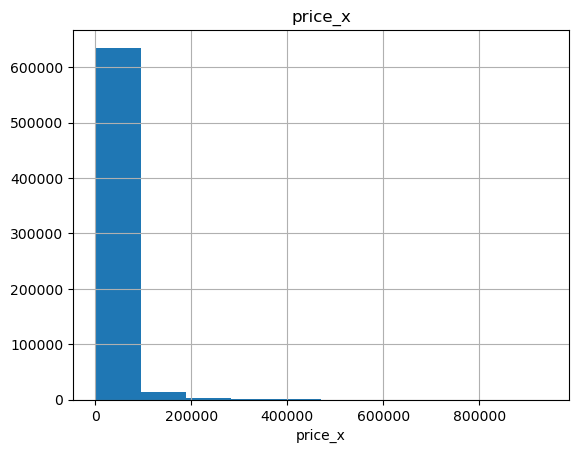

In [81]:
num_summary(df, "price_x", plot = True)

count   653721.000
mean     31630.966
std      28679.361
min        500.000
5%        7600.000
15%      12700.000
19%      14300.000
30%      18800.000
40%      22200.000
50%      25300.000
55%      27000.000
60%      29000.000
71%      34500.000
87.6%    49900.000
90%      55000.000
95%      74500.000
max     940000.000
Name: price_x, dtype: float64


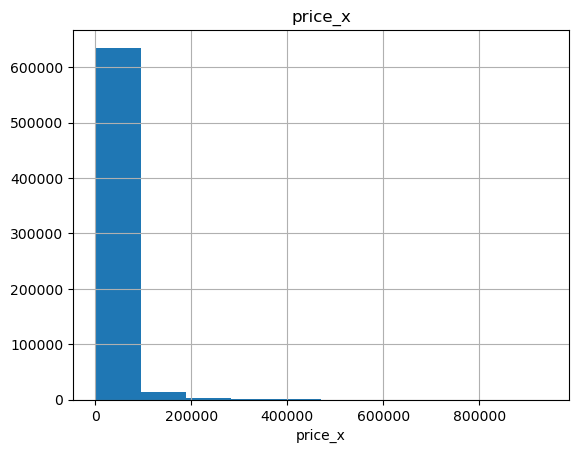


----------------------

count   653721.000
mean         2.221
std          1.266
min          0.000
5%           1.200
15%          1.500
19%          1.500
30%          1.600
40%          2.000
50%          2.000
55%          2.000
60%          2.000
71%          2.400
87.6%        3.000
90%          3.300
95%          4.000
max        120.000
Name: engine_displacement_num, dtype: float64


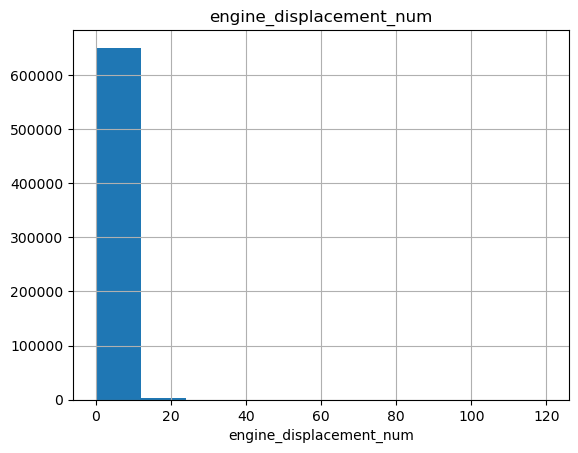


----------------------

count   653721.000
mean     31630.918
std      28679.394
min        500.000
5%        7600.000
15%      12700.000
19%      14300.000
30%      18800.000
40%      22200.000
50%      25300.000
55%      27000.000
60%      29000.000
71%      34500.000
87.6%    49900.000
90%      55000.000
95%      74500.000
max     940000.000
Name: price_y, dtype: float64


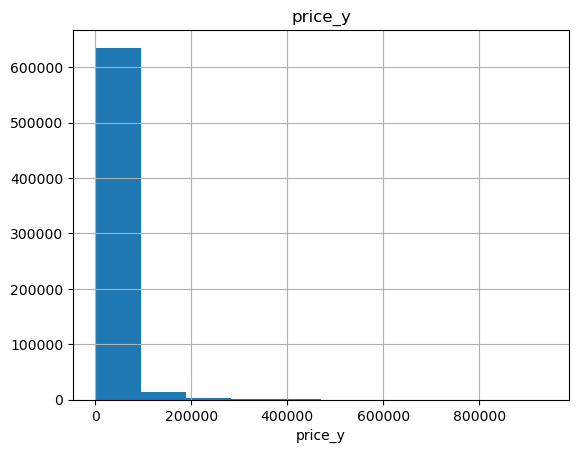


----------------------

count      653456.000
mean    558941474.943
std     151671835.115
min            78.000
5%      502002225.000
15%     503330735.000
19%     504300020.000
30%     507703344.000
40%     515354349.000
50%     552402929.000
55%     553250777.000
60%     554119797.000
71%     557630070.000
87.6%   707423511.227
90%     709444845.000
95%     775137007.000
max     999999690.000
Name: phone, dtype: float64


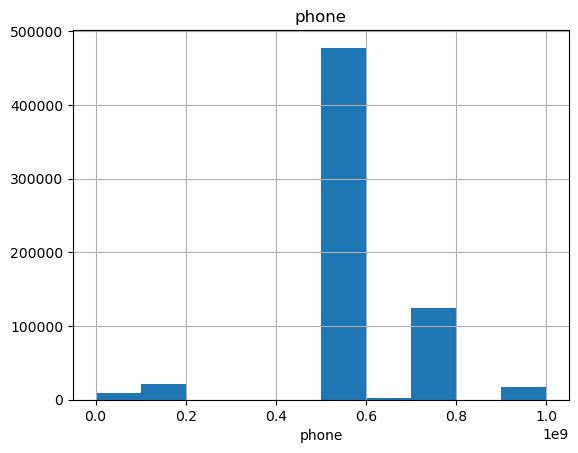


----------------------



In [82]:
for col in num_cols:
    num_summary(df, col, plot = True)
# reqem sutunlarinin qrafikle veziyyeti
    print("\n----------------------\n")

In [83]:
for col in num_cols:
    num_summary(df, col, plot = False)
# reqem sutunlarinin umumi neticesi
    print("\n----------------------\n")

count   653721.000
mean     31630.966
std      28679.361
min        500.000
5%        7600.000
15%      12700.000
19%      14300.000
30%      18800.000
40%      22200.000
50%      25300.000
55%      27000.000
60%      29000.000
71%      34500.000
87.6%    49900.000
90%      55000.000
95%      74500.000
max     940000.000
Name: price_x, dtype: float64

----------------------

count   653721.000
mean         2.221
std          1.266
min          0.000
5%           1.200
15%          1.500
19%          1.500
30%          1.600
40%          2.000
50%          2.000
55%          2.000
60%          2.000
71%          2.400
87.6%        3.000
90%          3.300
95%          4.000
max        120.000
Name: engine_displacement_num, dtype: float64

----------------------

count   653721.000
mean     31630.918
std      28679.394
min        500.000
5%        7600.000
15%      12700.000
19%      14300.000
30%      18800.000
40%      22200.000
50%      25300.000
55%      27000.000
60%      29000.000


# Feature Engineering 

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.width', 500)

In [86]:
df = pd.read_csv("cars.csv")
df

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.000,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.600,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.000,AZN,Şəmi,NaN,507687355.000,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.700,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.000,AZN,NaN,Lada Azərbaycan,554092445.000,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.000,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.000,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.000,USD,Anar,NaN,502126242.000,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.000,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.000,AZN,Babək,NaN,774999004.000,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-

In [87]:
df.columns

Index(['id_x', 'car_rel_url_x', 'datetime_scrape', 'name', 'price_x', 'currency_x', 'datetime_product', 'city', 'day', 'hour', 'attributes', 'production_year', 'engine_displacement_num', 'engine_displacement_unit', 'kilometrage_num', 'kilometrage_unit', 'barter', 'loan', 'salon', 'spare_parts', 'vip', 'featured', 'img_url', 'id_y', 'cars_id', 'car_rel_url_y', 'datetime', 'description', 'price_y', 'currency_y', 'owner_name', 'shop_name', 'phone', 'updated', 'views', 'vin', 'car_details_id_x',
       'Ban növü', 'Buraxılış ili', 'Hansı bazar üçün yığılıb', 'Marka', 'Model', 'Mühərrik', 'Qəzalı', 'Rəng', 'Sahiblər', 'Sürətlər qutusu', 'Vəziyyəti', 'Yeni', 'Yerlərin sayı', 'Yürüş', 'Ötürücü', 'Şəhər', 'car_details_id_y', 'car_rel_url', 'extra_info'],
      dtype='object')

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 653721 entries, 0 to 653720
Data columns (total 56 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id_x                      653721 non-null  object 
 1   car_rel_url_x             653721 non-null  object 
 2   datetime_scrape           653721 non-null  object 
 3   name                      653721 non-null  object 
 4   price_x                   653721 non-null  float64
 5   currency_x                653721 non-null  object 
 6   datetime_product          653721 non-null  object 
 7   city                      653721 non-null  object 
 8   day                       653721 non-null  object 
 9   hour                      653721 non-null  object 
 10  attributes                653721 non-null  object 
 11  production_year           653721 non-null  int64  
 12  engine_displacement_num   653721 non-null  float64
 13  engine_displacement_unit  647933 non-null  o

In [89]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price_x,653721.000,31630.966,28679.361,500.000,16800.000,25300.000,36800.000,940000.000
production_year,653721.000,1995.887,188.794,0.000,2009.000,2015.000,2019.000,2024.000
engine_displacement_num,653721.000,2.221,1.266,0.000,1.600,2.000,2.500,120.000
kilometrage_num,653721.000,156523.123,145894.858,0.000,55022.000,145000.000,222333.000,9900025.000
price_y,653721.000,31630.918,28679.394,500.000,16800.000,25300.000,36800.000,940000.000
phone,653456.000,558941474.943,151671835.115,78.000,506001358.500,552402929.000,558882698.000,999999690.000
views,653721.000,3740.732,10299.033,12.000,432.000,1367.000,3412.000,359317.000
Buraxılış ili,653721.000,2013.798,7.646,1938.000,2009.000,2015.000,2019.000,2024.000


In [90]:
import numpy as np

a = [2, 4, 6, 8, 10]

q1 = np.quantile(a, .25, method='weibull')
q2 = np.quantile(a, .5, method='weibull')
q3 = np.quantile(a, .75, method='weibull')

print(q1)
print(q2)
print(q3)

3.0
6.0
9.0


In [91]:
iqr = q3 - q1
iqr

6.0

In [92]:
def outlier_thresholds(df, column, q1=0.25, q3=0.75):
    q1_value = df[column].quantile(q1)
    q3_value = df[column].quantile(q3)
    iqr_value = q3_value - q1_value
    upper_limit = q3_value + 1.5 * iqr_value
    lower_limit = q1_value - 1.5 * iqr_value
    return lower_limit, upper_limit

In [93]:
outlier_thresholds(df, "kilometrage_num")

(-195944.5, 473299.5)

In [94]:
outlier_thresholds(df, "price_x")

(-13200.0, 66800.0)

In [95]:
up ,low = outlier_thresholds(df, "price_x")
up

-13200.0

In [96]:
low

66800.0

In [97]:
df[(df["price_x"] > low) | (df["price_x"] < up)]

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
76,18ca2911-d328-45f3-a38e-bfc164d7e292,/autos/8753566-land-rover-range-rover,2024-09-13 20:32:19.751157+00,Land Rover Range Rover,83300.000,$,"Bakı, dünən 23:29",bakı,13.09.2024,23:29,"2019, 3.0 L, 105 000 km",2019,3.000,L,105000,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,18ed2a97-8d90-4e84-a35f-58c8abec092e,18ca2911-d328-45f3-a38e-bfc164d7e292,/autos/8753566-land-rover-range-rover,2024-09-13 20:40:28.618345+00,Land Rover Range Rover Black Editon\n,83300.000,USD,Farid,NaN,702155600.000,13.09.2024,5423,NaN,18ed2a97-8d90-4e84-a35f-58c8abec092e,"Offroader / SUV, 5 qapı",2019,Rəsmi diler,Land Rover,Range Rover,3.0 L/249 a.g./Dizel,NaN,Qara,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,105 000 km,Tam,Bakı,18ed2a97-8d90-4e84-a35f-58c8abec092e,/autos/8753566-land-rover-range-rover,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
86,ef21dfe2-b41c-4637-a35a-8ed79c799958,/autos/8078267-mercedes-s-350-d-4matic,2024-09-13 20:32:19.751157+00,Mercedes S 350 d 4MATIC,112900.000,$,"Bakı, dünən 23:25",bakı,13.09.2024,23:25,"2021, 2.9 L, 121 000 km",2021,2.900,L,121000,km,Barter mümkündür,Kreditdədir,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,656e5976-42c1-429e-9b3f-fc6bef31dea7,ef21dfe2-b41c-4637-a35a-8ed79c799958,/autos/8078267-mercedes-s-350-d-4matic,2024-09-13 20:40:28.618345+00,Təçili satılır!!!! İdeal vəzitətdədi alмaniyad...,112900.000,USD,Qaçay,NaN,502104755.000,13.09.2024,1568,NaN,656e5976-42c1-429e-9b3f-fc6bef31dea7,Sedan,2021,Avropa,Mercedes,S 350 d 4MATIC,2.9 L/286 a.g./Dizel,NaN,Qara,2,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,121 000 km,Tam,Bakı,656e5976-42c1-429e-9b3f-fc6bef31dea7,/autos/8078267-mercedes-s-350-d-4matic,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
88,9f1f5dcd-3f4f-44bd-9c3d-f8c343e2c518,/autos/8728464-bmw-750e-xdrive,2024-09-13 20:32:19.751157+00,BMW 750e xDrive,180000.000,€,"Bakı, dünən 23:24",bakı,13.09.2024,23:24,"2024, 3.0 L, 0 km",2024,3.000,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,5ef95795-aa1d-4fae-91d9-1f13f68c2ab0,9f1f5dcd-3f4f-44bd-9c3d-f8c343e2c518,/autos/8728464-bmw-750e-xdrive,2024-09-13 20:40:28.618345+00,BMW AG-nin Azərbaycanda rəsmi idxalçısı olan “...,180000.000,EUR,NaN,BMW Azerbaijan,512301919.000,13.09.2024,26932,NaN,5ef95795-aa1d-4fae-91d9-1f13f68c2ab0,Sedan,2024,Rəsmi diler,BMW,750e xDrive,3.0 L/489 a.g./Plug-in Hibrid,NaN,Qara,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,5ef95795-aa1d-4fae-91d9-1f13f68c2ab0,/autos/8728464-bmw-750e-xdrive,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
129,b42f8227-ada6-4091-a37f-6ee52f47f777,/autos/8511433-mercedes-gle-53-amg-4matic-coupe,2024-09-13 20:32:19.751157+00,Mercedes GLE 53 AMG 4MATIC Coupe,105000.000,$,"Bakı, dünən 23:11",bakı,13.09.2024,23:11,"2022, 3.0 L, 18 000 km",2022,3.000,L,18000,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,df9d5e01-8d76-4305-bd7d-ea3e01f9bebe,b42f8227-ada6-4091-a37f-6ee52f47f777,/autos/8511433-mercedes-gle-53-amg-4matic-coupe,2024-09-13 20:40:28.618345+00,Resmi servisde qarantiyadadir ve orada qulluq ...,105000.000,USD,Ferid,NaN,509630015.000,13.09.2024,5864,NaN,df9d5e01-8d76-4305-bd7d-ea3e01f9bebe,SUV Kupe,2022,Rəsmi diler,Mercedes,GLE 53 AMG 4MATIC Coupe,3.0 L/435 a.g./Benzin,NaN,Qara,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,18 000 

In [98]:
df[(df["price_x"] < low) | (df["price_x"] > up)]

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.000,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.600,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.000,AZN,Şəmi,NaN,507687355.000,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.700,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.000,AZN,NaN,Lada Azərbaycan,554092445.000,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.000,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.000,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.000,USD,Anar,NaN,502126242.000,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.000,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.000,AZN,Babək,NaN,774999004.000,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-

In [99]:
df[(df["price_x"] < low) | (df["price_x"] > up)].head()

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.000,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.600,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.000,AZN,Şəmi,NaN,507687355.000,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.700,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.000,AZN,NaN,Lada Azərbaycan,554092445.000,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.000,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.000,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.000,USD,Anar,NaN,502126242.000,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.000,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.000,AZN,Babək,NaN,774999004.000,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-

In [100]:
df[(df["price_x"] < low) | (df["price_x"] > up)].head(12)

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.000,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.600,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.000,AZN,Şəmi,NaN,507687355.000,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.700,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.000,AZN,NaN,Lada Azərbaycan,554092445.000,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.000,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.000,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.000,USD,Anar,NaN,502126242.000,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.000,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.000,AZN,Babək,NaN,774999004.000,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-

In [101]:
df[(df["price_x"] > low) | (df["price_x"] < up)].index

Index([    76,     86,     88,    129,    170,    171,    224,    243,    263,    276,
       ...
       653545, 653561, 653597, 653638, 653653, 653663, 653687, 653693, 653695, 653720], dtype='int64', length=40931)

In [102]:
list(df[(df["price_x"] > low) | (df["price_x"] < up)].index)

[76,
 86,
 88,
 129,
 170,
 171,
 224,
 243,
 263,
 276,
 307,
 321,
 340,
 393,
 414,
 422,
 433,
 477,
 486,
 526,
 531,
 596,
 614,
 628,
 700,
 723,
 726,
 758,
 780,
 846,
 850,
 915,
 946,
 957,
 962,
 974,
 976,
 983,
 1031,
 1092,
 1096,
 1099,
 1159,
 1178,
 1195,
 1203,
 1229,
 1299,
 1308,
 1338,
 1343,
 1347,
 1348,
 1425,
 1430,
 1433,
 1437,
 1479,
 1494,
 1504,
 1550,
 1579,
 1582,
 1588,
 1603,
 1623,
 1642,
 1647,
 1659,
 1662,
 1677,
 1680,
 1684,
 1709,
 1727,
 1728,
 1732,
 1734,
 1754,
 1770,
 1822,
 1881,
 1889,
 1896,
 1907,
 1914,
 1926,
 1927,
 1942,
 1970,
 1990,
 2004,
 2019,
 2026,
 2031,
 2041,
 2046,
 2072,
 2074,
 2076,
 2077,
 2147,
 2148,
 2167,
 2183,
 2209,
 2267,
 2272,
 2274,
 2278,
 2313,
 2316,
 2317,
 2320,
 2322,
 2407,
 2437,
 2443,
 2446,
 2486,
 2495,
 2516,
 2520,
 2549,
 2574,
 2576,
 2612,
 2618,
 2650,
 2653,
 2662,
 2674,
 2697,
 2701,
 2702,
 2705,
 2706,
 2708,
 2714,
 2716,
 2721,
 2732,
 2733,
 2739,
 2810,
 2813,
 2816,
 2844,
 2848

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 653721 entries, 0 to 653720
Data columns (total 56 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id_x                      653721 non-null  object 
 1   car_rel_url_x             653721 non-null  object 
 2   datetime_scrape           653721 non-null  object 
 3   name                      653721 non-null  object 
 4   price_x                   653721 non-null  float64
 5   currency_x                653721 non-null  object 
 6   datetime_product          653721 non-null  object 
 7   city                      653721 non-null  object 
 8   day                       653721 non-null  object 
 9   hour                      653721 non-null  object 
 10  attributes                653721 non-null  object 
 11  production_year           653721 non-null  int64  
 12  engine_displacement_num   653721 non-null  float64
 13  engine_displacement_unit  647933 non-null  o

In [104]:
def get_column_types(dataframe, cat_th = 8, car_th = 13):
    # Kategorik sütunların tapılması
    cat_cols = [col for col in dataframe.columns if str(dataframe[col].dtypes) in ["category", "object", "bool"]]
    # Numerik olub kategorik kimi istifadə olunan sütunlar 
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < 8 and dataframe[col].dtypes in ["int", "float"]]
    # Kategorik olub kardinal olan sütunlar
    cat_but_car = [col for col in dataframe.columns if
                   dataframe[col].nunique() > 13 and str(dataframe[col].dtypes) in ["category", "object"]]
    # Kategorik sütunların birləşdirilməsi
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]
    # Numerik sütunların birləşdirilməsi
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes in ["int", "float"]]
    num_cols = [col for col in num_cols if col not in cat_cols]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')

    return cat_cols, num_cols, cat_but_car

In [105]:
cat_cols, num_cols, cat_but_car = get_column_types(df)

Observations: 653721
Variables: 56
cat_cols: 18
num_cols: 4
cat_but_car: 30
num_but_cat: 0


In [106]:
cat_cols

['currency_x',
 'engine_displacement_unit',
 'kilometrage_unit',
 'barter',
 'loan',
 'salon',
 'spare_parts',
 'vip',
 'featured',
 'currency_y',
 'Hansı bazar üçün yığılıb',
 'Qəzalı',
 'Sahiblər',
 'Sürətlər qutusu',
 'Vəziyyəti',
 'Yeni',
 'Yerlərin sayı',
 'Ötürücü']

In [107]:
num_cols

['price_x', 'engine_displacement_num', 'price_y', 'phone']

In [108]:
def grab_outliers(dataframe, col_name, index = False):
    low , up = outlier_thresholds(df, "price_x")
 # Outlier limitlərini tapır , limitdən kənarda olan dəyərləri müəyyən edirik. Əgər outlier sayı 10-dan çoxdursa  ilk 5-ni göstərir .Əks halda  hamısını göstərir
    if dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].shape[0] > 10:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].head())
    else:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))])

In [109]:
grab_outliers(df, "price_x")

                                     id_x                                    car_rel_url_x                datetime_scrape                              name    price_x currency_x   datetime_product  city         day   hour               attributes  production_year  engine_displacement_num engine_displacement_unit  kilometrage_num kilometrage_unit            barter         loan  salon spare_parts          vip       featured                                            img_url  \
76   18ca2911-d328-45f3-a38e-bfc164d7e292            /autos/8753566-land-rover-range-rover  2024-09-13 20:32:19.751157+00            Land Rover Range Rover  83300.000          $  Bakı, dünən 23:29  bakı  13.09.2024  23:29  2019, 3.0 L, 105 000 km             2019                    3.000                        L           105000               km               NaN          NaN    NaN         NaN  vipped-icon  featured-icon  https://turbo.azstatic.com/uploads/f460x343/20...   
86   ef21dfe2-b41c-4637-a35a-8ed79c79995

In [110]:
outlier_thresholds(df, "price_x")

(-13200.0, 66800.0)

## Solving Outlier Problems

In [111]:
def remove_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    # Outlier olmayan sətirlərin seçmək
    df_filtered = dataframe[~((dataframe[col_name] < low_limit) | (dataframe[col_name] > up_limit))]
    return df_filtered

In [112]:
df_clean = remove_outlier(df, "price_x")
df_clean

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.000,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.600,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.000,AZN,Şəmi,NaN,507687355.000,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.700,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.000,AZN,NaN,Lada Azərbaycan,554092445.000,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.000,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.000,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.000,USD,Anar,NaN,502126242.000,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.000,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.000,AZN,Babək,NaN,774999004.000,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-

In [113]:
df.shape

(653721, 56)

In [114]:
df_clean.shape

(612790, 56)

In [115]:
df.shape[0] - df_clean.shape[0]

40931

## Missing Values

In [117]:
df.isnull().values.any()

True

In [118]:
df.isnull().sum()

id_x                             0
car_rel_url_x                    0
datetime_scrape                  0
name                             0
price_x                          0
currency_x                       0
datetime_product                 0
city                             0
day                              0
hour                             0
attributes                       0
production_year                  0
engine_displacement_num          0
engine_displacement_unit      5788
kilometrage_num                  0
kilometrage_unit              5788
barter                      428168
loan                        490381
salon                       460382
spare_parts                 651959
vip                         364780
featured                    489886
img_url                          0
id_y                             0
cars_id                          0
car_rel_url_y                    0
datetime                         0
description                  15529
price_y             

In [119]:
df.notnull().sum()

id_x                        653721
car_rel_url_x               653721
datetime_scrape             653721
name                        653721
price_x                     653721
currency_x                  653721
datetime_product            653721
city                        653721
day                         653721
hour                        653721
attributes                  653721
production_year             653721
engine_displacement_num     653721
engine_displacement_unit    647933
kilometrage_num             653721
kilometrage_unit            647933
barter                      225553
loan                        163340
salon                       193339
spare_parts                   1762
vip                         288941
featured                    163835
img_url                     653721
id_y                        653721
cars_id                     653721
car_rel_url_y               653721
datetime                    653721
description                 638192
price_y             

In [120]:
# Datasetdə ən azı bir NaN olan sətirləri göstərmək
df[df.isnull().any(axis = 1)]

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.000,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.600,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.000,AZN,Şəmi,NaN,507687355.000,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.700,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.000,AZN,NaN,Lada Azərbaycan,554092445.000,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.000,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.000,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.000,USD,Anar,NaN,502126242.000,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.000,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.000,AZN,Babək,NaN,774999004.000,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-

In [121]:
def missing_values_table(df, return_nan_columns=False):
    # Burada NaN dəyəri olan bütün sütunlar seçilir
    nan_cols = [col for col in df.columns if df[col].isnull().sum() > 0]
    # Hər sütundakı NaN sayını tapir və çoxdan aza sıralayir
    nan_count = df[nan_cols].isnull().sum().sort_values(ascending=False)
    # Hər sütundakı NaN dəyərlərin faiz oranini tapir
    nan_ratio = (df[nan_cols].isnull().sum() / df.shape[0] * 100).sort_values(ascending=False)
    # NaN sayını və nisbətini birləşdirərək DataFrame yaradilir
    missing_df = pd.concat([nan_count, np.round(nan_ratio, 2)], axis=1, keys=['num_missing', 'percent_missing'])
    print(missing_df, end="\n")
    if return_nan_columns:
      return nan_cols

In [122]:
missing_values_table(df)

                          num_missing  percent_missing
Qəzalı                         651960           99.730
spare_parts                    651959           99.730
vin                            609450           93.230
loan                           490381           75.010
featured                       489886           74.940
salon                          460382           70.420
shop_name                      453761           69.410
barter                         428168           65.500
vip                            364780           55.800
Sahiblər                       221621           33.900
owner_name                     200225           30.630
Hansı bazar üçün yığılıb       189505           28.990
Yerlərin sayı                  165831           25.370
description                     15529            2.380
kilometrage_unit                 5788            0.890
engine_displacement_unit         5788            0.890
phone                             265            0.040
Vəziyyəti 

## Solving NAN Value Problems

In [123]:
df.dropna().shape

(0, 56)

In [124]:
df["Buraxılış ili"].fillna(df["Buraxılış ili"].mean()).isnull()

0         False
1         False
2         False
3         False
4         False
          ...  
653716    False
653717    False
653718    False
653719    False
653720    False
Name: Buraxılış ili, Length: 653721, dtype: bool

In [125]:
df.apply(lambda x: x.fillna(x.mean()) if x.dtype not in ['object', 'category', 'bool'] else x, axis = 0)

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.000,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.600,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.000,AZN,Şəmi,NaN,507687355.000,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.700,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.000,AZN,NaN,Lada Azərbaycan,554092445.000,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.000,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.000,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.000,USD,Anar,NaN,502126242.000,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.000,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.000,AZN,Babək,NaN,774999004.000,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-

# Feature Engineering Encoding

In [126]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.width', 500)
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, RobustScaler

In [127]:
df = pd.read_csv("cars.csv")
df.head()

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.000,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.600,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.000,AZN,Şəmi,NaN,507687355.000,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.700,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.000,AZN,NaN,Lada Azərbaycan,554092445.000,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.000,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.000,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.000,USD,Anar,NaN,502126242.000,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.000,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.000,AZN,Babək,NaN,774999004.000,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-

# Label Encoding & Binary Encoding

In [128]:
df["Yeni"].head()

0    Xeyr
1    Bəli
2    Xeyr
3    Xeyr
4    Xeyr
Name: Yeni, dtype: object

In [130]:
le = LabelEncoder()
le.fit_transform(df["Yeni"])[0:5]

array([1, 0, 1, 1, 1])

In [131]:
le.inverse_transform([0, 1])

array(['Bəli', 'Xeyr'], dtype=object)

In [132]:
def label_encoder(dataframe, binary_col):
    dataframe[binary_col] = dataframe[binary_col].map({dataframe[binary_col].unique()[0]:0,
                                                       dataframe[binary_col].unique()[1]:1})
    return dataframe

In [133]:
binary_cols = [col for col in df.columns if df[col].dtype not in [int, float]
               and df[col].nunique() == 2]

In [134]:
binary_cols

['Yeni']

In [135]:
for col in binary_cols:
    label_encoder(df, col)

In [136]:
df.head()

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.000,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.600,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.000,AZN,Şəmi,NaN,507687355.000,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",0,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.700,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.000,AZN,NaN,Lada Azərbaycan,554092445.000,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",1,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.000,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.000,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.000,USD,Anar,NaN,502126242.000,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",0,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.000,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.000,AZN,Babək,NaN,774999004.000,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",0,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-957a4c43c25d

In [138]:
#sütunlarda olan dəyərlərin neçə dəfə təkrarlanır
df["Ötürücü"].value_counts()

Ötürücü
Ön      317028
Tam     187243
Arxa    149450
Name: count, dtype: int64

In [142]:
#unikal (təkrar olmayan) dəyərlərin sayını
df["Ötürücü"].nunique()

3

In [143]:
#bütün fərqli (unikal) dəyərləri göstərir.
df["Ötürücü"].unique()

array(['Ön', 'Tam', 'Arxa'], dtype=object)

In [145]:
len(df["Ötürücü"].unique())

3

# One-Hot Encoding

In [147]:
df["Ötürücü"].value_counts()

Ötürücü
Ön      317028
Tam     187243
Arxa    149450
Name: count, dtype: int64

In [148]:
pd.get_dummies(df, columns = ["Ötürücü"]).head()

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Şəhər,car_details_id_y,car_rel_url,extra_info,Ötürücü_Arxa,Ötürücü_Tam,Ötürücü_Ön
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.000,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.600,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.000,AZN,Şəmi,NaN,507687355.000,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",0,5,270 000 km,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...,False,False,True
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.700,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.000,AZN,NaN,Lada Azərbaycan,554092445.000,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",1,5,0 km,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...,False,True,False
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.000,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.000,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.000,USD,Anar,NaN,502126242.000,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",0,8+,164 750 km,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...,False,True,False
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.000,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.000,AZN,Babək,NaN,774999004.000,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",0,NaN,126 000 km,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər*

In [150]:
# #İlk kateqoriyanı silir
# pd.get_dummies(df, columns = ["Ötürücü"], drop_first = True).head()
# #missing datanı itirməmək üçün istifadə olunur
# pd.get_dummies(df, columns = ["Ötürücü"], dummy_na = True).head()
#Eyni anda iki sütunu encode edir
pd.get_dummies(df, columns = ["Yeni", "Ötürücü"], drop_first = True).head()

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yerlərin sayı,Yürüş,Şəhər,car_details_id_y,car_rel_url,extra_info,Yeni_1,Ötürücü_Tam,Ötürücü_Ön
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.000,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.600,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.000,AZN,Şəmi,NaN,507687355.000,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",5,270 000 km,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...,False,False,True
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.700,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.000,AZN,NaN,Lada Azərbaycan,554092445.000,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",5,0 km,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...,True,True,False
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.000,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.000,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.000,USD,Anar,NaN,502126242.000,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",8+,164 750 km,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...,False,True,False
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.000,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.000,AZN,Babək,NaN,774999004.000,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",NaN,126 000 km,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış se

In [151]:
def one_hot_encoder(dataframe, categorical_cols, drop_first = True):
    dataframe = pd.get_dummies(dataframe, columns = categorical_cols, drop_first = drop_first)
    return dataframe

In [152]:
def grab_col_names(dataframe, cat_th=10, car_th=20):

    # Categorical columns
    cat_cols = [col for col in dataframe.columns
                if dataframe[col].dtype.name in ["category", "object", "bool"]]

    # Numerical but categorical
    num_but_cat = [col for col in dataframe.columns
                   if dataframe[col].nunique() < cat_th and dataframe[col].dtype in ["int64", "float64"]]

    # Categorical but cardinal
    cat_but_car = [col for col in dataframe.columns
                   if dataframe[col].nunique() > car_th and dataframe[col].dtype == "object"]

    # Final categorical columns
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # Numerical columns
    num_cols = [col for col in dataframe.columns
                if dataframe[col].dtype in ["int64", "float64"] and col not in cat_cols]

    # Information
    print("Observations:", dataframe.shape[0])
    print("Variables:", dataframe.shape[1])
    print("cat_cols:", len(cat_cols))
    print("num_cols:", len(num_cols))
    print("cat_but_car:", len(cat_but_car))
    print("num_but_cat:", len(num_but_cat))

    return cat_cols, num_cols, cat_but_car

In [153]:
cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 653721
Variables: 56
cat_cols: 19
num_cols: 8
cat_but_car: 29
num_but_cat: 1


In [154]:
#unikal dəyərlərinin sayı 3-dən 10-a qədər əlavə edir
ohe_cols = [col for col in df.columns if 2 < df[col].nunique() <= 11]
ohe_cols

['currency_x',
 'currency_y',
 'Hansı bazar üçün yığılıb',
 'Sahiblər',
 'Sürətlər qutusu',
 'Vəziyyəti',
 'Yerlərin sayı',
 'Ötürücü']

In [155]:
one_hot_encoder(df, ohe_cols).head()

,id_x,car_rel_url_x,datetime_scrape,name,price_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Marka,Model,Mühərrik,Qəzalı,Rəng,Yeni,Yürüş,Şəhər,car_details_id_y,car_rel_url,extra_info,currency_x_AZN,currency_x_€,currency_y_EUR,currency_y_USD,Hansı bazar üçün yığılıb_Avropa,Hansı bazar üçün yığılıb_Digər,Hansı bazar üçün yığılıb_Dubay,Hansı bazar üçün yığılıb_Koreya,Hansı bazar üçün yığılıb_Rusiya,Hansı bazar üçün yığılıb_Rəsmi diler,Hansı bazar üçün yığılıb_Yaponiya,Hansı bazar üçün yığılıb_Çin,Sahiblər_1,Sahiblər_2,Sahiblər_3,Sahiblər_4 və daha çox,Sürətlər qutusu_Mexaniki,Sürətlər qutusu_Reduktor,Sürətlər qutusu_Robot,Sürətlər qutusu_Variator,"Vəziyyəti_Vuruğu var, rənglənməyib","Vəziyyəti_Vuruğu yoxdur, rənglənib","Vəziyyəti_Vuruğu yoxdur, rənglənməyib",Yerlərin sayı_2,Yerlərin sayı_3,Yerlərin sayı_4,Yerlərin sayı_5,Yerlərin sayı_6,Yerlərin sayı_7,Yerlərin sayı_8+,Ötürücü_Tam,Ötürücü_Ön
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.000,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.600,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.000,Şəmi,NaN,507687355.000,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,0,270 000 km,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.000,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.700,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.000,NaN,Lada Azərbaycan,554092445.000,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,1,0 km,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.000,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.000,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.000,Anar,NaN,502126242.000,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,164 750 km,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...,False,False,False,True,False,False,False,False

# Rare Encoding

In [156]:
df = pd.read_csv("cars.csv")
df

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.000,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.600,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.000,AZN,Şəmi,NaN,507687355.000,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.700,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.000,AZN,NaN,Lada Azərbaycan,554092445.000,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.000,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.000,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.000,USD,Anar,NaN,502126242.000,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.000,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.000,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.000,AZN,Babək,NaN,774999004.000,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-

In [157]:
df["Şəhər"].value_counts()

Şəhər
Bakı        537681
Sumqayıt     47849
Gəncə        14142
Lənkəran      6347
Xırdalan      5424
             ...  
Xocalı           1
Zəngilan         1
Liman            1
Ağdərə           1
Qubadlı          1
Name: count, Length: 75, dtype: int64

In [160]:
def cat_summary(dataframe, col_name, plot=False):
    # Dəyərləri bir dəfə hesabla
    counts = dataframe[col_name].value_counts()
    ratios = 100 * counts / len(dataframe)
    
    # DataFrame şəklində çıxış
    summary_df = pd.DataFrame({col_name: counts, "Ratio (%)": ratios})
    print(summary_df)
    print("-" * 40)
    
    # Qrafik çıxışı
    if plot:
        plt.figure(figsize=(6,4))
        sns.countplot(x=col_name, data=dataframe)
        plt.title(f"{col_name} Count Plot")
        plt.xlabel(col_name)
        plt.ylabel("Count")
        plt.show()

In [161]:
for col in cat_cols:
    cat_summary(df, col)

            currency_x  Ratio (%)
currency_x                       
AZN             465598     71.223
$               182236     27.877
€                 5887      0.901
----------------------------------------
                          engine_displacement_unit  Ratio (%)
engine_displacement_unit                                     
L                                           647933     99.115
----------------------------------------
                  kilometrage_unit  Ratio (%)
kilometrage_unit                             
km                          647933     99.115
----------------------------------------
                  barter  Ratio (%)
barter                             
Barter mümkündür  225553     34.503
----------------------------------------
               loan  Ratio (%)
loan                          
Kreditdədir  163340     24.986
----------------------------------------
        salon  Ratio (%)
salon                   
Salon  193339     29.575
-------------------------